<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Infer%C3%AAncia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Inferência Estatística
Fabiano Antunes, Felipe Magno, Gabriela Araújo

In [ ]:
# 📦 Importação de bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem estatística
import statsmodels.api as sm
from statsmodels.stats.diagnostic import lilliefors, het_breuschpagan
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf

# Testes estatísticos
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import chi2_contingency
import itertools

## Teste 1 -  Felipe

1: Vamos analisar se existe diferença significativa no score de obsessões (Y-BOCS) entre pacientes do sexo feminino e masculino com Transtorno Obsessivo-Compulsivo (TOC).

Hipóteses.
Hipótese nula (H₀): Não há diferença significativa no score médio de obsessões Y-BOCS entre pacientes do sexo feminino e masculino.

Hipótese alternativa (H₁): Há diferença significativa no score médio de obsessões Y-BOCS entre pacientes do sexo feminino e masculino.

Nível de significância: α = 0.05

In [ ]:
# Carregar os dados
df = pd.read_csv('ocd_patient_dataset.csv')

df.head()

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


        count       mean        std  min   25%   50%   75%   max
Gender                                                          
Female  747.0  20.195448  11.719091  0.0  10.0  20.0  31.0  40.0
Male    753.0  19.901726  11.932920  0.0  10.0  20.0  30.0  40.0


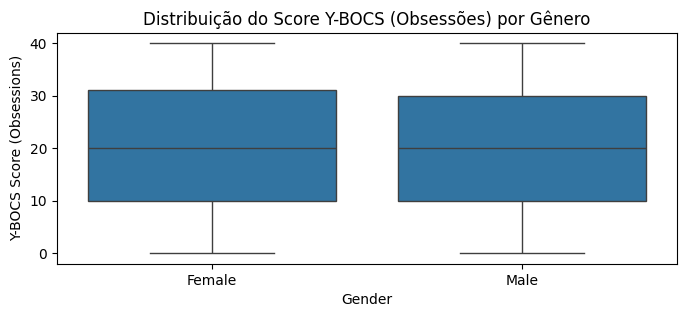

In [ ]:
# Descritiva
print(df.groupby('Gender')['Y-BOCS Score (Obsessions)'].describe())

# Visualização
plt.figure(figsize=(8, 3))
sns.boxplot(x='Gender', y='Y-BOCS Score (Obsessions)', data=df)
plt.title('Distribuição do Score Y-BOCS (Obsessões) por Gênero')
plt.show()

In [ ]:
#Teste de normalidade dos dados
#H₀: Os dados são normalmente distribuídos
#H₁: Os dados não são normalmente distribuídos

female_scores = df[df['Gender'] == 'Female']['Y-BOCS Score (Obsessions)']
male_scores = df[df['Gender'] == 'Male']['Y-BOCS Score (Obsessions)']

# Shapiro-Wilk
shapiro_female = stats.shapiro(female_scores)
shapiro_male = stats.shapiro(male_scores)

print(f"Shapiro-Wilk para mulheres: estatística={shapiro_female[0]}, p-valor={shapiro_female[1]}")
print(f"Shapiro-Wilk para homens: estatística={shapiro_male[0]}, p-valor={shapiro_male[1]}")

Shapiro-Wilk para mulheres: estatística=0.9549341314901955, p-valor=2.3545623948789993e-14
Shapiro-Wilk para homens: estatística=0.9505850603373208, p-valor=3.470521840570993e-15


Para ambos o P-valor é maior que 0,05. por tanto não rejeitamos a hipotese de normalidade.

In [ ]:
#Teste de Homogeneidade e Variância.
levene_test = stats.levene(female_scores, male_scores)
print(f"Teste de Levene: estatística={levene_test[0]}, p-valor={levene_test[1]}")

Teste de Levene: estatística=0.5243464834357745, p-valor=0.46910653120857493


In [ ]:
#Teste T
t_test = stats.ttest_ind(female_scores, male_scores, equal_var=True)
print(f"Teste t: estatística={t_test[0]}, p-valor={t_test[1]}")

Teste t: estatística=0.48092476381533655, p-valor=0.630640204204719


## P-Valor ≥ 0.05: Não há diferença significativa no score médio de obsessões Y-BOCS entre pacientes do sexo feminino e masculino.

## Teste 2 -  Felipe

Avaliar se existe diferença na proporção de pessoas com distúrbio do sono (Insônia) entre as diferentes ocupações.

Hipóteses:

Hipótese nula (H₀): A proporção de pessoas com insônia é a mesma em todas as ocupações.

Hipótese alternativa (H₁): Pelo menos uma ocupação tem proporção de insônia diferente das demais.


In [ ]:
#Carregar dados
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No
1,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No
2,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
3,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,No
4,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,No


Como estamos comparando proporções em mais de dois grupos categóricos, o teste mais adequado é o teste qui-quadrado de independência.

Validação das Suposições:

Dados categóricos: Sim (ocupação × distúrbio do sono).

Amostras independentes: Sim (cada pessoa pertence a apenas uma ocupação).

Frequências esperadas: Devemos verificar se pelo menos 80% das células têm frequência esperada ≥ 5.



In [ ]:
print(df[['Occupation', 'Sleep Disorder']].head())

# Converter "Sleep Disorder" em binário (Insônia = True, outros = False)
df['Has_Insomnia'] = df['Sleep Disorder'] == 'Insomnia'

# Criar tabela de contingência
observed_table = pd.crosstab(df['Occupation'], df['Has_Insomnia'])

# Renomear colunas
observed_table.columns = ['No_Insomnia', 'Insomnia']
print(observed_table)

  Occupation Sleep Disorder
0     Doctor             No
1     Doctor             No
2    Teacher       Insomnia
3     Doctor             No
4     Doctor             No
             No_Insomnia  Insomnia
Occupation                        
Accountant            30         7
Doctor                64         3
Engineer              57         5
Lawyer                42         2
Nurse                  9         3
Salesperson            2        29
Teacher                9        27


In [ ]:
#Cálculo da frequência esperada pra cada celula.

observed = np.array([
    [30,  7],
    [64,  3],
    [57,  5],
    [42,  2],
    [ 9,  3],
    [ 2, 29],
    [ 9, 27]
])

chi2, p, dof, expected = chi2_contingency(observed)
print("Frequências esperadas:\n", expected)

Frequências esperadas:
 [[27.26989619  9.73010381]
 [49.38062284 17.61937716]
 [45.69550173 16.30449827]
 [32.42906574 11.57093426]
 [ 8.84429066  3.15570934]
 [22.84775087  8.15224913]
 [26.53287197  9.46712803]]


Conclusão: Proporções significativamente menores que o esperado.

In [ ]:
#Teste Qui-Quadrado
chi2, p, dof, expected = chi2_contingency(observed)
print(f"Estatística qui-quadrado: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Estatística qui-quadrado: 155.28
p-value: 0.0000


# p-value 0.0000 (p < 0.05) - Rejeitamos a hipótese nula.

# Conclusão: Há diferença estatisticamente significativa na proporção de insônia entre as ocupações.

In [ ]:
#Teste post hoc para saber em quais ocupações estão as diferenças
# Lista de ocupações
occupations = observed_table.index

# Ajuste de Bonferroni: α = 0.05 / número de comparações
alpha = 0.05
n_comparisons = len(occupations) * (len(occupations) - 1) / 2
adjusted_alpha = alpha / n_comparisons

print(f"α ajustado (Bonferroni): {adjusted_alpha:.4f}")

# Comparações pareadas
for pair in itertools.combinations(occupations, 2):
    subset = observed_table.loc[list(pair)]
    _, p_posthoc, _, _ = chi2_contingency(subset)
    if p_posthoc < adjusted_alpha:
        print(f"{pair[0]} vs {pair[1]}: p = {p_posthoc:.4f} (SIGNIFICATIVO)")
    else:
        print(f"{pair[0]} vs {pair[1]}: p = {p_posthoc:.4f}")

α ajustado (Bonferroni): 0.0024
Accountant vs Doctor: p = 0.0409
Accountant vs Engineer: p = 0.1996
Accountant vs Lawyer: p = 0.0900
Accountant vs Nurse: p = 0.9665
Accountant vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Accountant vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Doctor vs Engineer: p = 0.6322
Doctor vs Lawyer: p = 1.0000
Doctor vs Nurse: p = 0.0601
Doctor vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Doctor vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Engineer vs Lawyer: p = 0.7475
Engineer vs Nurse: p = 0.2219
Engineer vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Engineer vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Lawyer vs Nurse: p = 0.1028
Lawyer vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Lawyer vs Teacher: p = 0.0000 (SIGNIFICATIVO)
Nurse vs Salesperson: p = 0.0000 (SIGNIFICATIVO)
Nurse vs Teacher: p = 0.0059
Salesperson vs Teacher: p = 0.0867


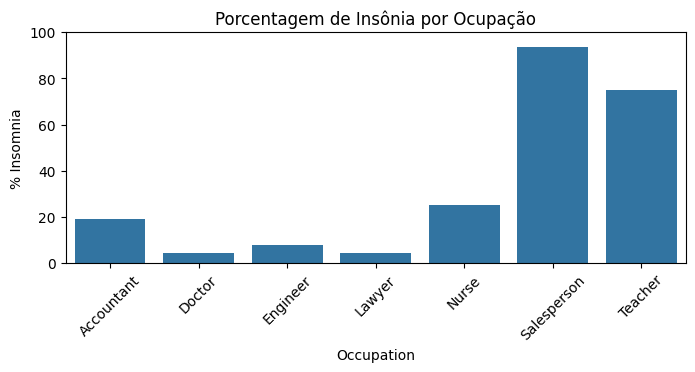

In [ ]:
# Calcular porcentagem de insônia por ocupação
observed_table['% Insomnia'] = observed_table['Insomnia'] / (observed_table['No_Insomnia'] + observed_table['Insomnia']) * 100

# Gráfico de barras
plt.figure(figsize=(8, 3))
sns.barplot(data=observed_table.reset_index(), x='Occupation', y='% Insomnia')
plt.title("Porcentagem de Insônia por Ocupação")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.show()

Ocupações de Alto Risco de Insônia:
Salesperson (29/31 = 93.5% com insônia)
Teacher (27/36 = 75% com insônia)

Ocupações de Baixo Risco:
Doctor, Engineer, Lawyer, Accountant (proporções de insônia < 10%, exceto Nurse).

Nurse tem uma proporção intermediária (3/12 = 25%), mas não difere significativamente das demais após correção rigorosa.

## Teste 3 - Fabiano

PERGUNTA Nº 3: *Uma empresa de tecnologia está constantemente analisando o mercado e buscando novas formas de converter os clientes (fechar contratos).
Pensando nisso, ela investiu em uma empresa de treinamento de vendedores
(VendaPro Academy) que diz que o seu método de vendas é superior aos
métodos convencionais. Para verificar essa hipótese, a empresa de
tecnologia vai avaliar o desempenho dos funcionários.
Vamos comparar o desempenho de 35 vendedores ao utilizar o método
convencional de vendas e o método obtido pelo treinamento com a empresa
VendaPro Academy, medindo o tempo de trabalho em horas necessário
para alcançar uma meta de 10 contratos vendidos. Os dados estão na
base de dados “treinamentoVendedores.csv”. Determine ao nível de 2% de
significância, se o método da empresa VendaPro Academy é realmente
superior ao método convencional da empresa*

Teste de Normalidade dos Dados (Shapiro-Wilk)

In [ ]:
# Carregar o dataset
df = pd.read_csv('TreinamentoVendedores.csv')

# --- Teste de Normalidade para a coluna 'Convencional' ---
print("--- Teste de Normalidade para 'Convencional' ---")
# Realiza o teste de Shapiro-Wilk para a coluna 'Convencional'
shapiro_convencional = stats.shapiro(df['Convencional'])
print(f"Shapiro-Wilk Test para 'Convencional':")
print(f"  Estatística W: {shapiro_convencional.statistic:.4f}")
print(f"  Valor-p: {shapiro_convencional.pvalue:.4f}")

# Plotar histograma para visualizar a distribuição
plt.figure(figsize=(10, 6))
sns.histplot(df['Convencional'], kde=True) # kde=True adiciona a estimativa de densidade do kernel
plt.title('Distribuição do Tempo - Método Convencional')
plt.xlabel('Tempo (horas)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('normalidade_convencional_hist.png')
plt.close()

# Plotar Q-Q plot para comparar os quantis dos dados com os de uma distribuição normal
plt.figure(figsize=(10, 6))
stats.probplot(df['Convencional'], dist="norm", plot=plt) # dist="norm" especifica uma distribuição normal
plt.title('Q-Q Plot - Método Convencional')
plt.xlabel('Quantis Teóricos')
plt.ylabel('Quantis Observados')
plt.savefig('normalidade_convencional_qqplot.png')
plt.close()

# --- Teste de Normalidade para a coluna 'VendaPro' ---
print("\n--- Teste de Normalidade para 'VendaPro' ---")
# Realiza o teste de Shapiro-Wilk para a coluna 'VendaPro'
shapiro_vendapro = stats.shapiro(df['VendaPro'])
print(f"Shapiro-Wilk Test para 'VendaPro':")
print(f"  Estatística W: {shapiro_vendapro.statistic:.4f}")
print(f"  Valor-p: {shapiro_vendapro.pvalue:.4f}")

# Plotar histograma para visualizar a distribuição
plt.figure(figsize=(10, 6))
sns.histplot(df['VendaPro'], kde=True)
plt.title('Distribuição do Tempo - VendaPro Academy')
plt.xlabel('Tempo (horas)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('normalidade_vendapro_hist.png')
plt.close()

# Plotar Q-Q plot para comparar os quantis dos dados com os de uma distribuição normal
plt.figure(figsize=(10, 6))
stats.probplot(df['VendaPro'], dist="norm", plot=plt)
plt.title('Q-Q Plot - VendaPro Academy')
plt.xlabel('Quantis Teóricos')
plt.ylabel('Quantis Observados')
plt.savefig('normalidade_vendapro_qqplot.png')
plt.close()


--- Teste de Normalidade para 'Convencional' ---
Shapiro-Wilk Test para 'Convencional':
  Estatística W: 0.9783
  Valor-p: 0.7043

--- Teste de Normalidade para 'VendaPro' ---
Shapiro-Wilk Test para 'VendaPro':
  Estatística W: 0.9700
  Valor-p: 0.4436


## Exemplo 1: Teste Z para uma única proporção
### Suponha que uma empresa afirma que 70% dos seus clientes renovam contratos. Você coleta uma amostra de 150 clientes e descobre que 95 renovaram.
### Queremos testar se a proporção de renovação na sua amostra é significativamente diferente de 70%.


In [ ]:

# Número total de observações na amostra (n)
n_amostra = 150
# Número de sucessos (renovações) na amostra (x)
sucessos_amostra = 95
# Proporção populacional hipotetizada sob H0 (p0)
p0 = 0.70

# Calcular a proporção amostral
p_amostra = sucessos_amostra / n_amostra

print(f"--- Teste Z para uma Proporção ---")
print(f"Proporção amostral observada: {p_amostra:.4f}")
print(f"Proporção populacional hipotetizada (H0): {p0:.4f}")

# Realizar o Teste Z para proporção
# 'count' é o número de sucessos na amostra
# 'nobs' é o número total de observações na amostra
# 'value' é a proporção hipotetizada sob H0
z_statistic_1prop, p_value_1prop = sm.stats.proportions_ztest(count=sucessos_amostra, nobs=n_amostra, value=p0)

print(f"\nResultados do Teste Z para uma Proporção:")
print(f"  Estatística Z: {z_statistic_1prop:.4f}")
print(f"  Valor-p (bilateral): {p_value_1prop:.4f}")

# Nível de significância
alpha = 0.05

# Conclusão para o teste bilateral
if p_value_1prop < alpha:
    print(f"  Conclusão: Rejeitamos H0. Há evidências de que a proporção de renovação na amostra é significativamente diferente de {p0}.")
else:
    print(f"  Conclusão: Não rejeitamos H0. Não há evidências de que a proporção de renovação na amostra seja significativamente diferente de {p0}.")



--- Teste Z para uma Proporção ---
Proporção amostral observada: 0.6333
Proporção populacional hipotetizada (H0): 0.7000

Resultados do Teste Z para uma Proporção:
  Estatística Z: -1.6943
  Valor-p (bilateral): 0.0902
  Conclusão: Não rejeitamos H0. Não há evidências de que a proporção de renovação na amostra seja significativamente diferente de 0.7.


## Exemplo 2: Teste Z para comparar duas proporções independentes
### Suponha que você quer comparar a taxa de conversão de dois designs de website (A e B).
### Design A: 80 conversões em 200 visitas.
### Design B: 65 conversões em 180 visitas.


--- Teste Z para Comparar Duas Proporções Independentes ---


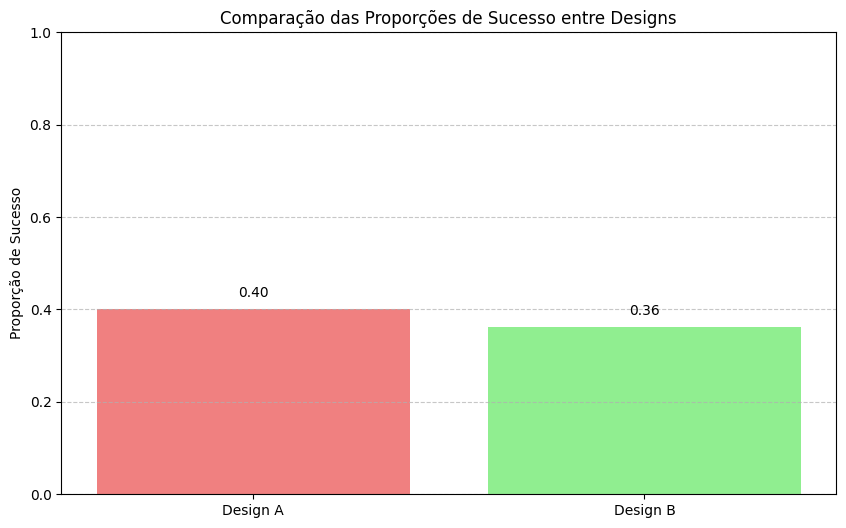

In [ ]:
print("\n--- Teste Z para Comparar Duas Proporções Independentes ---")

# Dados do Grupo A (Design A)
sucessos_A = 80
n_A = 200

# Dados do Grupo B (Design B)
sucessos_B = 65
n_B = 180

# 'count' é uma lista ou array com o número de sucessos para cada grupo
# 'nobs' é uma lista ou array com o número total de observações para cada grupo
counts = [sucessos_A, sucessos_B]
nobs = [n_A, n_B]
# --- Geração de Gráficos para o Teste Z de Duas Proporções ---
# Visualização das proporções dos dois grupos
proporcao_A = sucessos_A / n_A
proporcao_B = sucessos_B / n_B

grupos = ['Design A', 'Design B']
proporcoes = [proporcao_A, proporcao_B]

plt.figure(figsize=(10, 6))
plt.bar(grupos, proporcoes, color=['lightcoral', 'lightgreen'])
plt.ylabel('Proporção de Sucesso')
plt.title('Comparação das Proporções de Sucesso entre Designs')
plt.ylim(0, 1) # Proporções vão de 0 a 1
for i, v in enumerate(proporcoes):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Teste de Levene para homogeneidade de variâncias

## Aplicamos às colunas 'Convencional' e 'VendaPro' como se fossem grupos independentes para demonstrar o teste. Lembre-se que em seu caso, os dados são pareados.

In [ ]:
levene_test = stats.levene(df['Convencional'], df['VendaPro'])

print("Teste de Homogeneidade de Variâncias (Teste de Levene)")
print(f"Estatística de Levene: {levene_test.statistic:.4f}")
print(f"Valor-p: {levene_test.pvalue:.4f}")

# Nível de significância
alpha = 0.05

# Conclusão
if levene_test.pvalue > alpha:
    print(f"Conclusão: Não rejeitamos H0. Há evidências de homogeneidade de variâncias entre os métodos Convencional e VendaPro (assumindo-os como grupos independentes).")
else:
    print(f"Conclusão: Rejeitamos H0. Há evidências de que as variâncias entre os métodos Convencional e VendaPro são significativamente diferentes (assumindo-os como grupos independentes).")


Teste de Homogeneidade de Variâncias (Teste de Levene)
Estatística de Levene: 0.0014
Valor-p: 0.9699
Conclusão: Não rejeitamos H0. Há evidências de homogeneidade de variâncias entre os métodos Convencional e VendaPro (assumindo-os como grupos independentes).


# Teste t Independente para Médias (Assumindo Variâncias Iguais)
##  Este teste é aplicado como se 'Convencional' e 'VendaPro' fossem grupos independentes (o que não é o caso em seu dataset real, que é pareado).
## O parâmetro 'equal_var=True' indica que estamos assumindo variâncias iguais,
## o que é justificado se o Teste de Levene não rejeitou H0.

In [ ]:

independent_ttest_equal_var = stats.ttest_ind(df['Convencional'], df['VendaPro'], equal_var=True)

print("--- Teste t Independente para Médias (Variâncias Iguais) ---")
print(f"Estatística t: {independent_ttest_equal_var.statistic:.4f}")
print(f"Valor-p (bilateral): {independent_ttest_equal_var.pvalue:.4f}")

# Nível de significância
alpha = 0.05

# Conclusão (para teste bilateral)
if independent_ttest_equal_var.pvalue < alpha:
    print(f"Conclusão: Rejeitamos H0. Há evidências de que as médias dos tempos dos métodos Convencional e VendaPro são significativamente diferentes (considerando-os grupos independentes e variâncias iguais).")
else:
    print(f"Conclusão: Não rejeitamos H0. Não há evidências de que as médias dos tempos dos métodos Convencional e VendaPro sejam significativamente diferentes (considerando-os grupos independentes e variâncias iguais).")



--- Teste t Independente para Médias (Variâncias Iguais) ---
Estatística t: 4.6354
Valor-p (bilateral): 0.0000
Conclusão: Rejeitamos H0. Há evidências de que as médias dos tempos dos métodos Convencional e VendaPro são significativamente diferentes (considerando-os grupos independentes e variâncias iguais).


# Exemplo do Teste t Independente para Médias (Variâncias Desiguais - Teste de Welch)


In [ ]:
# Se o Teste de Levene tivesse rejeitado H0 (variâncias desiguais), usaríamos equal_var=False
print("\nTeste t Independente para Médias (Variâncias Desiguais - Teste de Welch) ")
independent_ttest_unequal_var = stats.ttest_ind(df['Convencional'], df['VendaPro'], equal_var=False)

print(f"Estatística t (Welch): {independent_ttest_unequal_var.statistic:.4f}")
print(f"Valor-p (bilateral): {independent_ttest_unequal_var.pvalue:.4f}")

# Conclusão (para teste bilateral com Welch)
if independent_ttest_unequal_var.pvalue < alpha:
    print(f"Conclusão: Rejeitamos H0. Há evidências de que as médias dos tempos dos métodos Convencional e VendaPro são significativamente diferentes (considerando-os grupos independentes e variâncias desiguais).")
else:
    print(f"Conclusão: Não rejeitamos H0. Não há evidências de que as médias dos tempos dos métodos Convencional e VendaPro sejam significativamente diferentes (considerando-os grupos independentes e variâncias desiguais).")



Teste t Independente para Médias (Variâncias Desiguais - Teste de Welch) 
Estatística t (Welch): 4.6354
Valor-p (bilateral): 0.0000
Conclusão: Rejeitamos H0. Há evidências de que as médias dos tempos dos métodos Convencional e VendaPro são significativamente diferentes (considerando-os grupos independentes e variâncias desiguais).


# Teste de Hipótese para Média (Teste t de uma amostra)
## Exemplo: Testar se a média do tempo do método 'Convencional' é significativamente diferente de 50 horas ---
## Suponha que, historicamente, a meta era atingida em 50 horas com o método antigo.
## Queremos saber se o método convencional atual difere dessa média histórica.
### Valor hipotetizado para a média populacional (mu_0)

In [ ]:

mu_0 = 50

# Realiza o teste t de uma amostra
# 'df['Convencional']' é a amostra de dados
# 'popmean=mu_0' é a média populacional hipotetizada sob H0
one_sample_ttest = stats.ttest_1samp(df['Convencional'], popmean=mu_0)

print(f"Teste t de uma Amostra para 'Convencional' (vs. média hipotética de {mu_0} horas) ")
print(f"Estatística t: {one_sample_ttest.statistic:.4f}")
print(f"Valor-p (bilateral): {one_sample_ttest.pvalue:.4f}")

# Nível de significância
alpha = 0.05

# Conclusão para o teste bilateral
if one_sample_ttest.pvalue < alpha:
    print(f"Conclusão: Rejeitamos H0. Há evidências de que a média do tempo do método Convencional é significativamente diferente de {mu_0} horas.")
else:
    print(f"Conclusão: Não rejeitamos H0. Não há evidências de que a média do tempo do método Convencional seja significativamente diferente de {mu_0} horas.")


Teste t de uma Amostra para 'Convencional' (vs. média hipotética de 50 horas) 
Estatística t: -0.8421
Valor-p (bilateral): 0.4056
Conclusão: Não rejeitamos H0. Não há evidências de que a média do tempo do método Convencional seja significativamente diferente de 50 horas.


 # Gráficos de histograma e Q-Q plot ao script do Canvas "Teste de Hipótese para Média (Teste t de uma amostra)

Os gráficos serão exibidos na tela agora, lado a lado.

--- Teste de Normalidade para 'Convencional' ---
Teste de Shapiro-Wilk para 'Convencional':
  Estatística W: 0.9783
  Valor-p: 0.7043


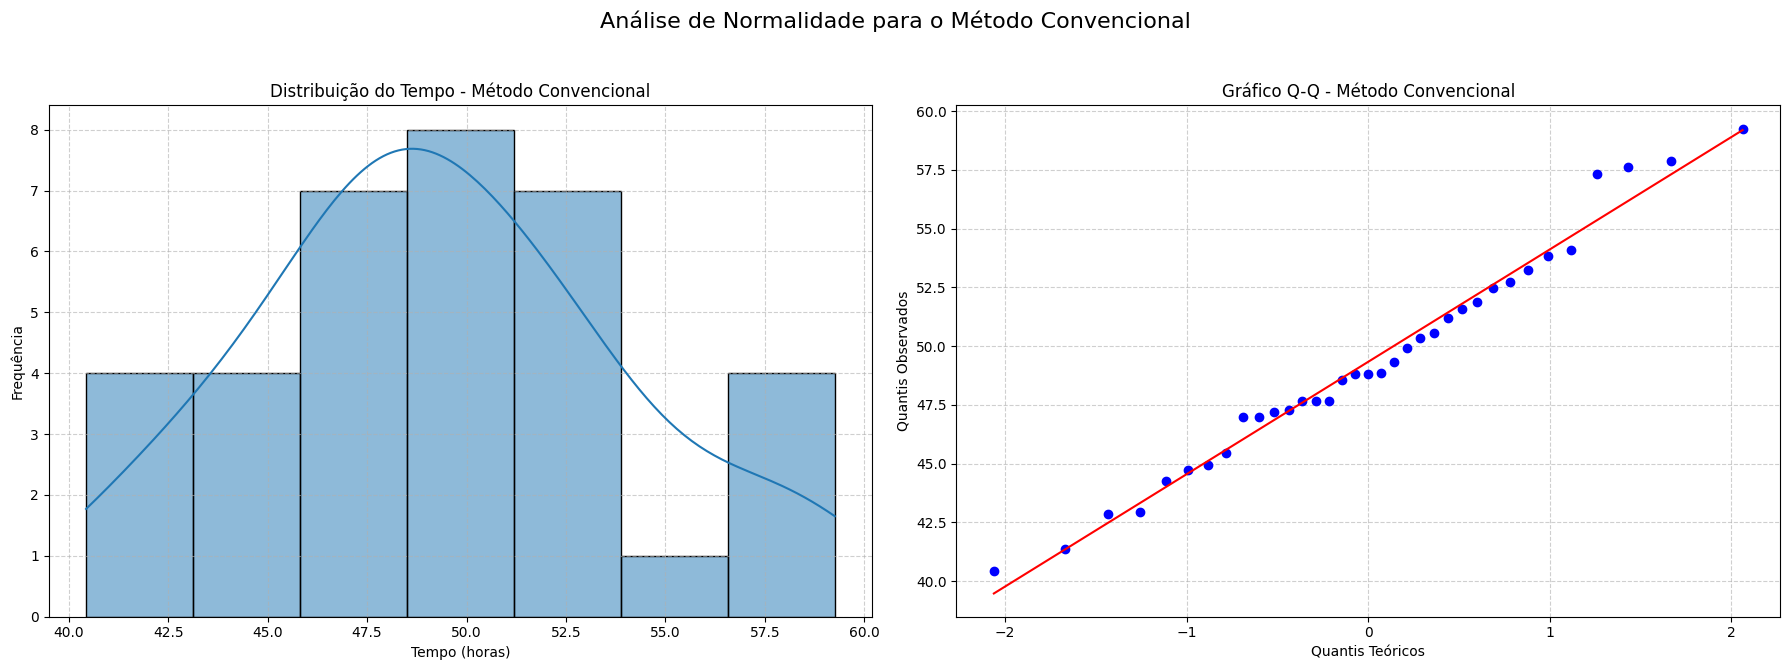


--- Teste de Normalidade para 'VendaPro' ---
Teste de Shapiro-Wilk para 'VendaPro':
  Estatística W: 0.9700
  Valor-p: 0.4436


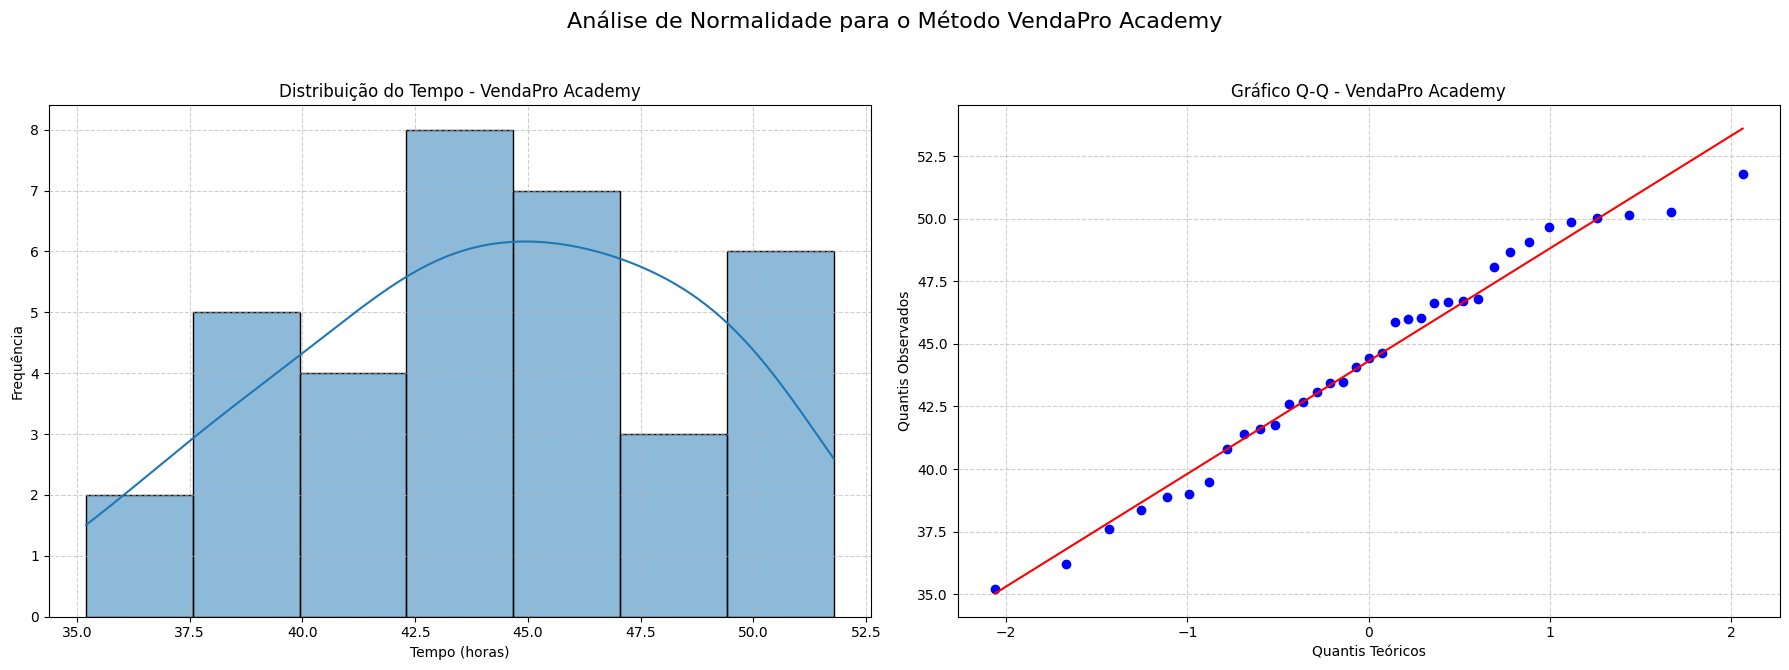

In [ ]:
# Carrega o dataset
df = pd.read_csv('TreinamentoVendedores.csv')

# Obtém o diretório de trabalho atual para fins informativos
diretorio_saida = os.getcwd()
print(f"Os gráficos serão exibidos na tela agora, lado a lado.\n")

# --- Teste de Normalidade para a coluna 'Convencional' ---
print("--- Teste de Normalidade para 'Convencional' ---")
# Realiza o teste de Shapiro-Wilk para a coluna 'Convencional'
shapiro_convencional = stats.shapiro(df['Convencional'])
print(f"Teste de Shapiro-Wilk para 'Convencional':")
print(f"  Estatística W: {shapiro_convencional.statistic:.4f}")
print(f"  Valor-p: {shapiro_convencional.pvalue:.4f}")

# Cria uma figura com 1 linha e 2 colunas de subplots para 'Convencional'
fig_convencional, axes_convencional = plt.subplots(1, 2, figsize=(18, 7)) # Aumenta o tamanho para melhor visualização lado a lado

# Plota o histograma na primeira sub-figura
sns.histplot(df['Convencional'], kde=True, ax=axes_convencional[0])
axes_convencional[0].set_title('Distribuição do Tempo - Método Convencional')
axes_convencional[0].set_xlabel('Tempo (horas)')
axes_convencional[0].set_ylabel('Frequência')
axes_convencional[0].grid(True, linestyle='--', alpha=0.6)

# Plota o gráfico Q-Q na segunda sub-figura
stats.probplot(df['Convencional'], dist="norm", plot=axes_convencional[1])
axes_convencional[1].set_title('Gráfico Q-Q - Método Convencional')
axes_convencional[1].set_xlabel('Quantis Teóricos')
axes_convencional[1].set_ylabel('Quantis Observados')
axes_convencional[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Análise de Normalidade para o Método Convencional', fontsize=16) # Título geral para a figura
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição de títulos
plt.show() # Exibe o gráfico interativamente

# --- Teste de Normalidade para a coluna 'VendaPro' ---
print("\n--- Teste de Normalidade para 'VendaPro' ---")
# Realiza o teste de Shapiro-Wilk para a coluna 'VendaPro'
shapiro_vendapro = stats.shapiro(df['VendaPro'])
print(f"Teste de Shapiro-Wilk para 'VendaPro':")
print(f"  Estatística W: {shapiro_vendapro.statistic:.4f}")
print(f"  Valor-p: {shapiro_vendapro.pvalue:.4f}")

# Cria uma figura com 1 linha e 2 colunas de subplots para 'VendaPro'
fig_vendapro, axes_vendapro = plt.subplots(1, 2, figsize=(18, 7)) # Aumenta o tamanho

# Plota o histograma na primeira sub-figura
sns.histplot(df['VendaPro'], kde=True, ax=axes_vendapro[0])
axes_vendapro[0].set_title('Distribuição do Tempo - VendaPro Academy')
axes_vendapro[0].set_xlabel('Tempo (horas)')
axes_vendapro[0].set_ylabel('Frequência')
axes_vendapro[0].grid(True, linestyle='--', alpha=0.6)

# Plota o gráfico Q-Q na segunda sub-figura
stats.probplot(df['VendaPro'], dist="norm", plot=axes_vendapro[1])
axes_vendapro[1].set_title('Gráfico Q-Q - VendaPro Academy')
axes_vendapro[1].set_xlabel('Quantis Teóricos')
axes_vendapro[1].set_ylabel('Quantis Observados')
axes_vendapro[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Análise de Normalidade para o Método VendaPro Academy', fontsize=16) # Título geral para a figura
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout
plt.show() # Exibe o gráfico interativamente


# Teste de Homogeneidade de Variâncias (Teste de Levene) com Gráfico

Os gráficos para o Teste de Levene serão exibidos na tela.

--- Teste de Homogeneidade de Variâncias (Teste de Levene) ---
Estatística de Levene: 0.0014
Valor-p: 0.9699
Conclusão: Não rejeitamos H0. Há evidências de homogeneidade de variâncias entre os métodos Convencional e VendaPro (assumindo-os como grupos independentes).


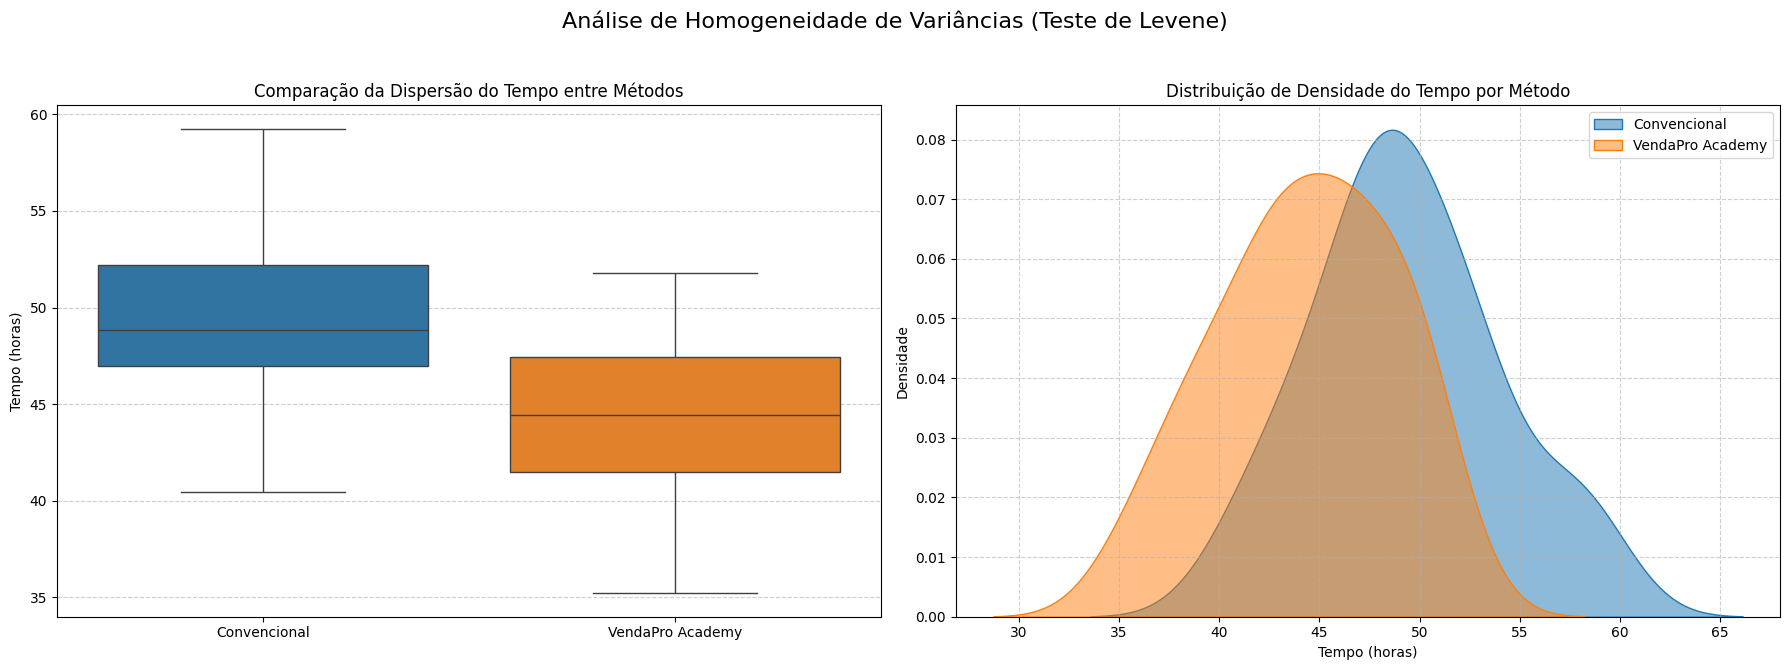

In [ ]:

# Carrega o dataset
df = pd.read_csv('TreinamentoVendedores.csv')

print(f"Os gráficos para o Teste de Levene serão exibidos na tela.\n")

# --- Teste de Levene para homogeneidade de variâncias ---
# Aplicamos às colunas 'Convencional' e 'VendaPro' como se fossem grupos independentes
# para demonstrar o teste. Lembre-se que em seu caso, os dados são pareados.
levene_test = stats.levene(df['Convencional'], df['VendaPro'])

print("--- Teste de Homogeneidade de Variâncias (Teste de Levene) ---")
print(f"Estatística de Levene: {levene_test.statistic:.4f}")
print(f"Valor-p: {levene_test.pvalue:.4f}")

# Nível de significância
alpha = 0.05

# Conclusão
if levene_test.pvalue > alpha:
    print(f"Conclusão: Não rejeitamos H0. Há evidências de homogeneidade de variâncias entre os métodos Convencional e VendaPro (assumindo-os como grupos independentes).")
else:
    print(f"Conclusão: Rejeitamos H0. Há evidências de que as variâncias entre os métodos Convencional e VendaPro são significativamente diferentes (assumindo-os como grupos independentes).")

# --- Geração de Gráficos para o Teste de Levene ---

# Cria uma figura com 1 linha e 2 colunas de subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Box plots são úteis para visualizar a dispersão e comparar variâncias
sns.boxplot(data=df[['Convencional', 'VendaPro']], ax=axes[0])
axes[0].set_title('Comparação da Dispersão do Tempo entre Métodos')
axes[0].set_ylabel('Tempo (horas)')
# CORREÇÃO: Definir os ticks antes de definir os rótulos para evitar o UserWarning
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Convencional', 'VendaPro Academy'])
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico de densidade (KDE) para visualizar a distribuição completa e dispersão
sns.kdeplot(df['Convencional'], label='Convencional', fill=True, alpha=0.5, ax=axes[1])
sns.kdeplot(df['VendaPro'], label='VendaPro Academy', fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Distribuição de Densidade do Tempo por Método')
axes[1].set_xlabel('Tempo (horas)')
axes[1].set_ylabel('Densidade')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Análise de Homogeneidade de Variâncias (Teste de Levene)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() # Exibe o gráfico interativamente


# Teste Z para Proporção (Exemplo Genérico) com Gráfico

Estatística Z: -1.6943

A Estatística Z é o valor calculado a partir dos seus dados amostrais. Ela mede a distância, em termos de desvios padrão, entre a proporção da sua amostra (95 sucessos em 150 tentativas, ou seja, 63.33%) e a proporção hipotetizada pela hipótese nula (70%).

Um valor negativo (-1.6943) indica que a proporção da sua amostra (63.33%) é menor do que a proporção hipotetizada (70%). Quanto maior o valor absoluto da Estatística Z, mais longe a sua amostra está da hipótese nula.

Valor-p (bilateral): 0.0902

O valor-p (ou p-value) é a probabilidade de observar uma Estatística Z tão extrema (ou mais extrema) quanto a que você calculou, assumindo que a hipótese nula é verdadeira.

Neste caso, um valor-p de 0.0902 significa que há uma probabilidade de aproximadamente 9.02% de obter uma proporção amostral como 63.33% (ou mais distante de 70%, em qualquer direção), se a verdadeira proporção da população fosse realmente 70%.

O termo "bilateral" significa que o teste está verificando se a proporção da amostra é diferente (maior ou menor) da proporção hipotetizada.

Conclusão: Não rejeitamos H0. Não há evidências de que a proporção de renovação na amostra seja significativamente diferente de 0.7.

Para chegar a essa conclusão, comparamos o valor-p com o seu nível de significância (α), que no script está definido como 0.05 (ou 5%).

A regra é:

Se valor-p < α: Rejeitamos a hipótese nula (H0​).

Se valor-p >= α: Não rejeitamos a hipótese nula (H0​).

No seu resultado, 0.0902 (valor-p) é maior que 0.05 (α).

Portanto, como o valor-p é maior que o nível de significância, não teremos  evidências estatísticas suficientes para rejeitar a hipótese nula.

Isso significa que, com base nos seus dados e no nível de significância escolhido, não podemos afirmar que a proporção de renovação na amostra é significativamente diferente de 70%.

 Em outras palavras, a diferença observada (63.33% vs. 70%) pode ser apenas devido ao acaso da amostragem.

Os gráficos para o Teste Z para Proporção serão exibidos na tela, lado a lado.

--- Teste Z para uma Proporção ---
Proporção amostral observada: 0.6333
Proporção populacional hipotetizada (H0): 0.7000

Resultados do Teste Z para uma Proporção:
  Estatística Z: -1.6943
  Valor-p (bilateral): 0.0902
  Conclusão: Não rejeitamos H0. Não há evidências de que a proporção de renovação na amostra seja significativamente diferente de 0.7.

--- Teste Z para Comparar Duas Proporções Independentes ---

Resultados do Teste Z para Duas Proporções:
  Estatística Z: 0.7792
  Valor-p (bilateral): 0.4359
  Conclusão: Não rejeitamos H0. Não há evidências de que as proporções de conversão dos dois designs sejam significativamente diferentes.


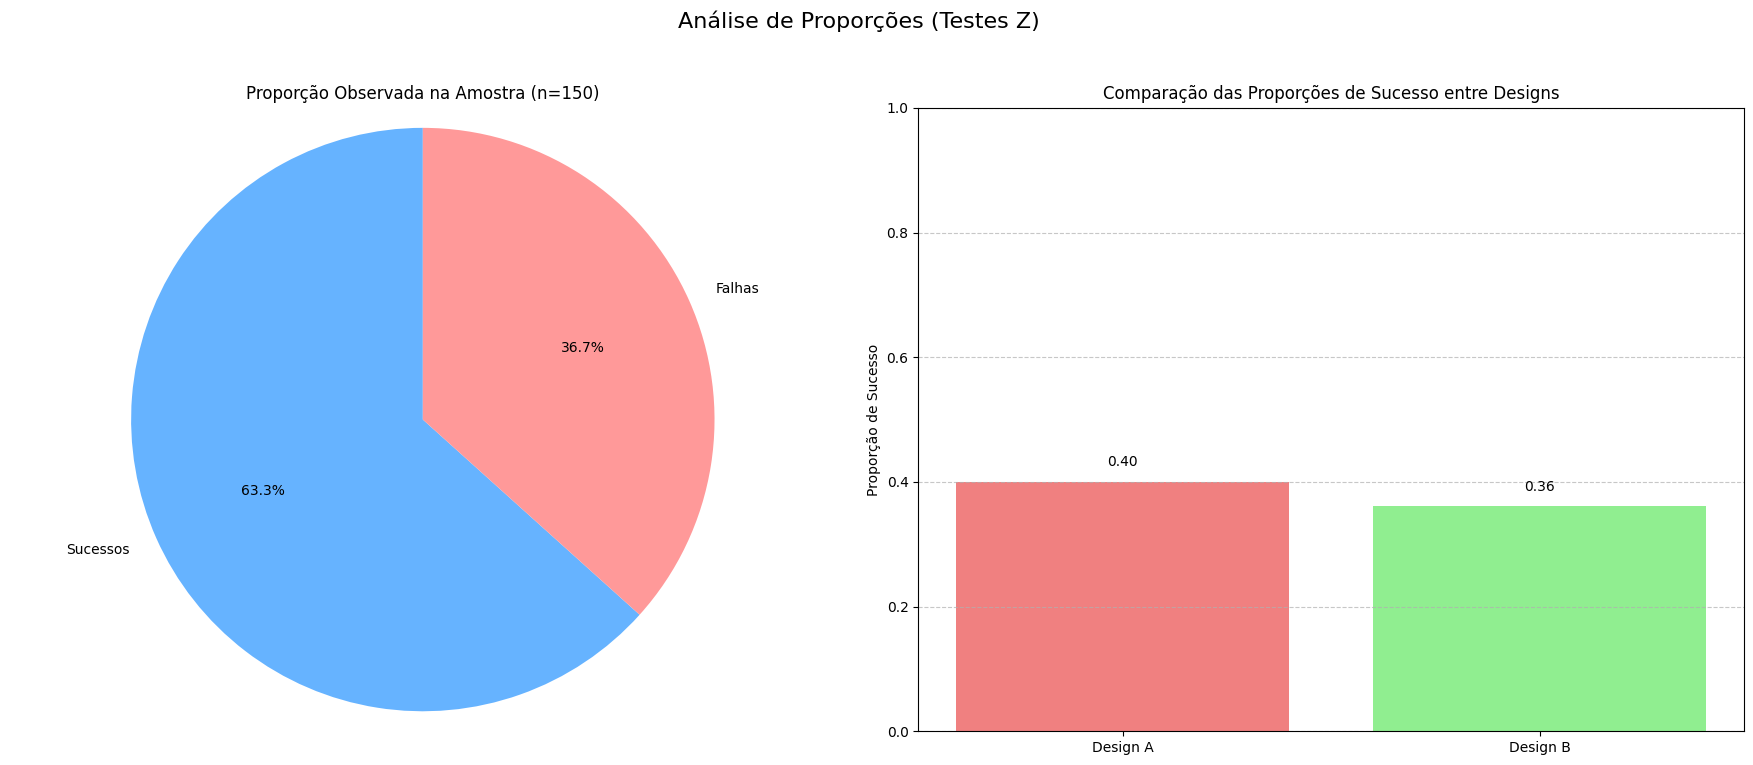

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

print(f"Os gráficos para o Teste Z para Proporção serão exibidos na tela, lado a lado.\n")

# --- Exemplo 1: Teste Z para uma única proporção ---
# Suponha que uma empresa afirma que 70% dos seus clientes renovam contratos.
# Você coleta uma amostra de 150 clientes e descobre que 95 renovaram.
# Queremos testar se a proporção de renovação na sua amostra é significativamente diferente de 70%.

# Número total de observações na amostra (n)
n_amostra = 150
# Número de sucessos (renovações) na amostra (x)
sucessos_amostra = 95
# Proporção populacional hipotetizada sob H0 (p0)
p0 = 0.70

# Calcular a proporção amostral
p_amostra = sucessos_amostra / n_amostra

print(f"--- Teste Z para uma Proporção ---")
print(f"Proporção amostral observada: {p_amostra:.4f}")
print(f"Proporção populacional hipotetizada (H0): {p0:.4f}")

# Realizar o Teste Z para proporção
# 'count' é o número de sucessos na amostra
# 'nobs' é o número total de observações na amostra
# 'value' é a proporção hipotetizada sob H0
z_statistic_1prop, p_value_1prop = sm.stats.proportions_ztest(count=sucessos_amostra, nobs=n_amostra, value=p0)

print(f"\nResultados do Teste Z para uma Proporção:")
print(f"  Estatística Z: {z_statistic_1prop:.4f}")
print(f"  Valor-p (bilateral): {p_value_1prop:.4f}")

# Nível de significância
alpha = 0.05

# Conclusão para o teste bilateral
if p_value_1prop < alpha:
    print(f"  Conclusão: Rejeitamos H0. Há evidências de que a proporção de renovação na amostra é significativamente diferente de {p0}.")
else:
    print(f"  Conclusão: Não rejeitamos H0. Não há evidências de que a proporção de renovação na amostra seja significativamente diferente de {p0}.")

# --- Exemplo 2: Teste Z para comparar duas proporções independentes ---
# Suponha que você quer comparar a taxa de conversão de dois designs de website (A e B).
# Design A: 80 conversões em 200 visitas.
# Design B: 65 conversões em 180 visitas.

print("\n--- Teste Z para Comparar Duas Proporções Independentes ---")

# Dados do Grupo A (Design A)
sucessos_A = 80
n_A = 200

# Dados do Grupo B (Design B)
sucessos_B = 65
n_B = 180

# 'count' é uma lista ou array com o número de sucessos para cada grupo
# 'nobs' é uma lista ou array com o número total de observações para cada grupo
counts = [sucessos_A, sucessos_B]
nobs = [n_A, n_B]

# Realizar o Teste Z para duas proporções
z_statistic_2prop, p_value_2prop = sm.stats.proportions_ztest(count=counts, nobs=nobs)

print(f"\nResultados do Teste Z para Duas Proporções:")
print(f"  Estatística Z: {z_statistic_2prop:.4f}")
print(f"  Valor-p (bilateral): {p_value_2prop:.4f}")

# Conclusão para o teste bilateral
if p_value_2prop < alpha:
    print(f"  Conclusão: Rejeitamos H0. Há evidências de que as proporções de conversão dos dois designs são significativamente diferentes.")
else:
    print(f"  Conclusão: Não rejeitamos H0. Não há evidências de que as proporções de conversão dos dois designs sejam significativamente diferentes.")

# --- Geração de Gráficos para o Teste Z de Proporções (Lado a Lado) ---

# Cria uma figura com 1 linha e 2 colunas de subplots para exibir os gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) # Aumenta o tamanho para melhor visualização

# --- Gráfico para o Teste Z de uma Proporção (Gráfico de Pizza) ---
labels_1 = ['Sucessos', 'Falhas']
sizes_1 = [sucessos_amostra, n_amostra - sucessos_amostra]
colors_1 = ['#66b3ff', '#ff9999']

axes[0].pie(sizes_1, labels=labels_1, colors=colors_1, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Proporção Observada na Amostra (n={n_amostra})')
axes[0].axis('equal') # Garante que o gráfico de pizza seja um círculo.

# --- Gráfico para o Teste Z de Duas Proporções (Gráfico de Barras) ---
proporcao_A = sucessos_A / n_A
proporcao_B = sucessos_B / n_B

grupos = ['Design A', 'Design B']
proporcoes = [proporcao_A, proporcao_B]

axes[1].bar(grupos, proporcoes, color=['lightcoral', 'lightgreen'])
axes[1].set_ylabel('Proporção de Sucesso')
axes[1].set_title('Comparação das Proporções de Sucesso entre Designs')
axes[1].set_ylim(0, 1) # Proporções vão de 0 a 1
for i, v in enumerate(proporcoes):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Análise de Proporções (Testes Z)', fontsize=16) # Título geral para a figura
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição de títulos
plt.show() # Exibe a figura com ambos os gráficos


### RESPONDENDO A PERGUNTA PRINCIPAL
`Hipóteses testadas, as suposições do teste e as conclusões obtidas, incluindo a necessidade`

1. Teste de Normalidade dos Dados (Shapiro-Wilk Test)
Suposições:

Amostra aleatória e independente da população.

Os dados são contínuos.

Conclusões dos Resultados Obtidos:

Comparação do valor-p com o nível de significância (α, e.g., 0.05):

Se valor-p > α: Não rejeitamos H
0
​
 .

Conclusão: Há evidências de que os dados da variável em questão (e.g., 'Convencional' ou 'VendaPro') seguem uma distribuição normal. Isso suporta o uso de testes paramétricos.

Se valor-p <= α: Rejeitamos H
0
​
 .

Conclusão: Há evidências de que os dados da variável em questão não seguem uma distribuição normal. Nesses casos, testes não paramétricos seriam mais apropriados ou transformações dos dados deveriam ser consideradas.

Gráficos: Os histogramas e Q-Q plots fornecem uma visualização importante para apoiar ou questionar a conclusão do teste estatístico.

2. Teste Z para Proporção
Cenário A: Teste Z para uma Única Proporção
Suposições:

Amostra aleatória e independente.

Os dados são categóricos (binários: sucesso/falha).

O tamanho da amostra é grande o suficiente para que a distribuição amostral da proporção seja aproximadamente normal (geralmente, n⋅p
0
​
 ≥10 e n⋅(1−p
0
​
 )≥10).

Conclusões dos Resultados Obtidos:

Comparação do valor-p (bilateral) com o nível de significância (α, e.g., 0.05):

Se valor-p < α: Rejeitamos H
0
​
 .

Conclusão: Há evidências estatísticas de que a proporção observada na amostra é significativamente diferente da proporção populacional hipotetizada.

Se valor-p >= α: Não rejeitamos H
0
​
 .

Conclusão: Não há evidências estatísticas de que a proporção observada na amostra seja significativamente diferente da proporção populacional hipotetizada. A diferença observada pode ser devido ao acaso.

Gráficos: O gráfico de pizza visualiza a proporção observada, ajudando a entender o contexto da conclusão.

Cenário B: Teste Z para Comparar Duas Proporções Independentes
Suposições:

Duas amostras independentes e aleatórias.

Os dados são categóricos (binários: sucesso/falha) para ambos os grupos.

Os tamanhos das amostras são grandes o suficiente para que as distribuições amostrais das proporções sejam aproximadamente normais para ambos os grupos (geralmente, n⋅p≥10 e n⋅(1−p)≥10 para cada grupo).

Conclusões dos Resultados Obtidos:

Comparação do valor-p (bilateral) com o nível de significância (α, e.g., 0.05):

Se valor-p < α: Rejeitamos H
0
​
 .

Conclusão: Há evidências estatísticas de que as proporções de sucesso entre os dois grupos são significativamente diferentes.

Se valor-p >= α: Não rejeitamos H
0
​
 .

Conclusão: Não há evidências estatísticas de que as proporções de sucesso entre os dois grupos sejam significativamente diferentes.

Gráficos: O gráfico de barras compara visualmente as proporções de sucesso dos dois grupos.

3. Teste de Homogeneidade de Variâncias (Teste de Levene)
Suposições:

Amostras aleatórias e independentes.

Os dados são contínuos.

O teste de Levene é robusto a desvios da normalidade.

Conclusões dos Resultados Obtidos:

Comparação do valor-p com o nível de significância (α, e.g., 0.05):

Se valor-p > α: Não rejeitamos H
0
​
 .

Conclusão: Há evidências de homogeneidade de variâncias entre os grupos. Isso permite o uso de testes paramétricos que assumem variâncias iguais (e.g., o teste t de Student padrão).

Se valor-p <= α: Rejeitamos H
0
​
 .

Conclusão: Há evidências de que as variâncias entre os grupos são significativamente diferentes. Nesses casos, testes paramétricos que não assumem variâncias iguais (como o Teste t de Welch) ou testes não paramétricos seriam mais apropriados.

Gráficos: Box plots e gráficos de densidade (KDE) são úteis para visualizar a dispersão e comparar as variâncias entre os grupos.

4. Teste de Hipótese Independente para Médias (Teste t independente de Student - Variâncias Iguais)
Suposições:

Duas amostras independentes e aleatórias.

Os dados são contínuos.

Os dados em cada grupo são aproximadamente normalmente distribuídos (verificado com o Teste de Normalidade).

Homogeneidade de variâncias entre os grupos (verificado com o Teste de Levene).

Conclusões dos Resultados Obtidos:

Comparação do valor-p (bilateral ou unilateral) com o nível de significância (α, e.g., 0.05):

Se valor-p < α: Rejeitamos H
0
​
 .

Conclusão: Há evidências estatísticas de que as médias dos dois grupos são significativamente diferentes.

Se valor-p >= α: Não rejeitamos H
0
​
 .

Conclusão: Não há evidências de que as médias dos dois grupos sejam significativamente diferentes.

Gráficos: Box plots e violin plots são excelentes para comparar visualmente as distribuições e médias dos dois grupos.

Post-hoc: Não aplicável, pois o teste t independente compara apenas dois grupos. Se houvesse mais de dois grupos e um teste inicial (como ANOVA) fosse significativo, um teste post-hoc seria necessário para identificar quais pares de grupos são significativamente diferentes.

5. Teste de Hipótese para Média (Teste t de uma amostra)
Suposições:

Amostra aleatória e independente.

Os dados são contínuos.

Os dados da amostra são aproximadamente normalmente distribuídos (verificado com o Teste de Normalidade).

Conclusões dos Resultados Obtidos:

Comparação do valor-p (bilateral ou unilateral) com o nível de significância (α, e.g., 0.05):

Se valor-p < α: Rejeitamos H
0
​
 .

Conclusão: Há evidências estatísticas de que a média da amostra é significativamente diferente do valor hipotetizado.

Se valor-p >= α: Não rejeitamos H
0
​
 .

Conclusão: Não há evidências de que a média da amostra seja significativamente diferente do valor hipotetizado.

Gráficos: O histograma e o Q-Q plot visualizam a distribuição dos dados da amostra em relação à média hipotetizada.

*Post-hoc: Não aplicável para este teste.*


Gerando gráficos para o Teste t Pareado...

--- Resultados do Teste t Pareado ---
T-Estatística: 4.2555
Valor-p (Unilateral, para H1: Convencional > VendaPro): 0.0001
Nível de Significância (alpha): 0.02
Conclusão: Rejeitamos a hipótese nula. Há evidências estatísticas de que o método da VendaPro Academy é superior ao método convencional (o tempo para atingir a meta é menor).


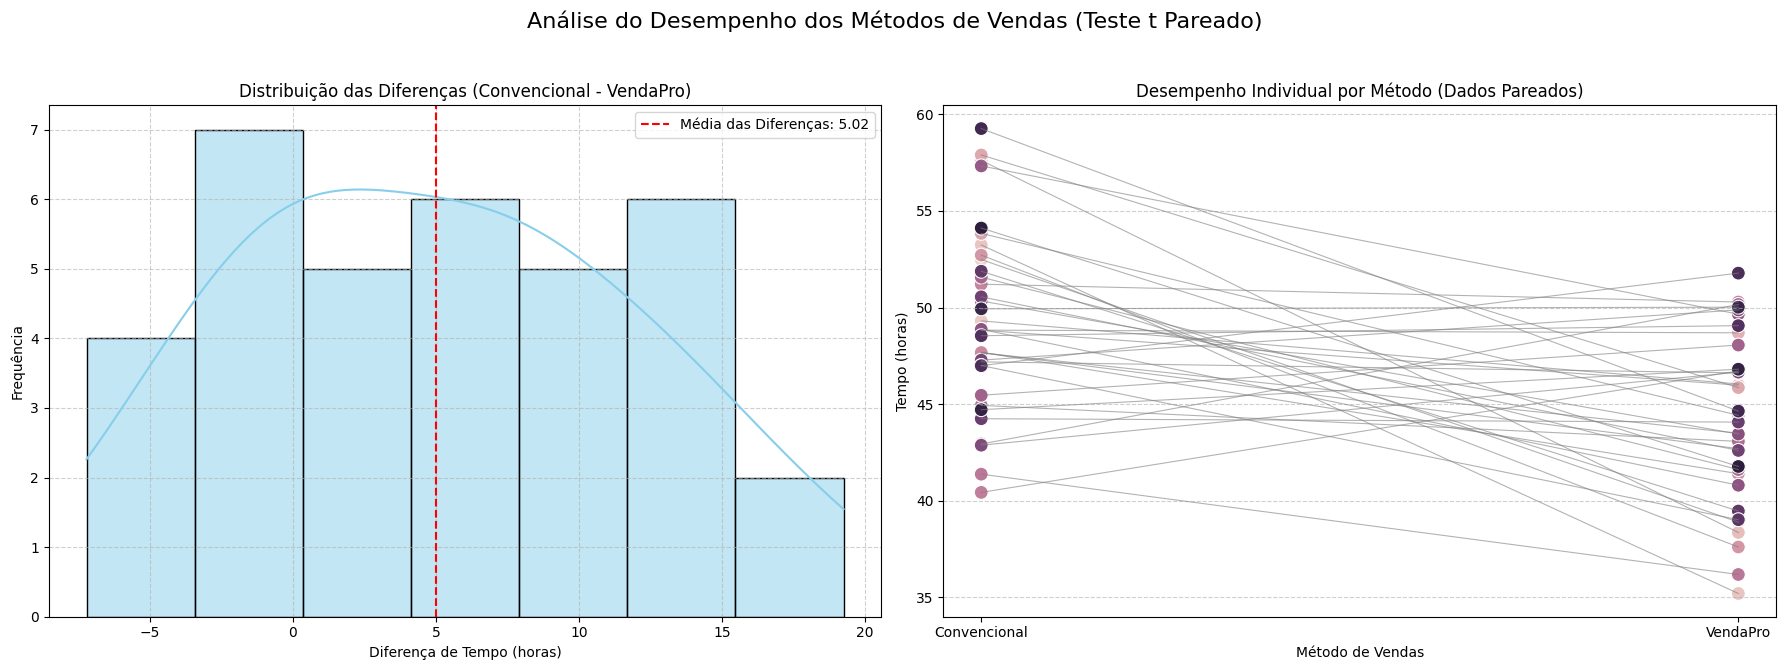

In [ ]:
# Carrega o dataset
df = pd.read_csv('TreinamentoVendedores.csv')

print("Gerando gráficos para o Teste t Pareado...\n")

# --- 1. Cálculo das Diferenças e Teste t Pareado ---
# Calcula a diferença entre o tempo do método Convencional e VendaPro para cada vendedor
df['Diferença'] = df['Convencional'] - df['VendaPro']

# Realiza o Teste t Pareado
# Nossa hipótese alternativa é que VendaPro é superior (tempo menor),
# então Convencional - VendaPro deve ser > 0.
# stats.ttest_rel retorna um p-valor bilateral. Para um unilateral (Convencional > VendaPro),
# dividimos o p-valor por 2 se a estatística t for positiva.
t_statistic, p_value_two_tailed = stats.ttest_rel(df['Convencional'], df['VendaPro'])

# Ajusta o p-valor para o teste unilateral (H1: Convencional > VendaPro)
if t_statistic > 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    # Se a estatística t for negativa, significa que VendaPro não é superior,
    # então o p-valor unilateral para H1: Convencional > VendaPro seria alto (próximo de 1).
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)

print(f"--- Resultados do Teste t Pareado ---")
print(f"T-Estatística: {t_statistic:.4f}")
print(f"Valor-p (Unilateral, para H1: Convencional > VendaPro): {p_value_one_tailed:.4f}")

# Nível de significância
alpha = 0.02
print(f"Nível de Significância (alpha): {alpha}")

# Conclusão
if p_value_one_tailed < alpha:
    print(f"Conclusão: Rejeitamos a hipótese nula. Há evidências estatísticas de que o método da VendaPro Academy é superior ao método convencional (o tempo para atingir a meta é menor).")
else:
    print(f"Conclusão: Não rejeitamos a hipótese nula. Não há evidências estatísticas de que o método da VendaPro Academy seja superior ao método convencional.")

# --- 2. Geração de Gráficos ---

# Cria uma figura com 1 linha e 2 colunas de subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Histograma das Diferenças ---
sns.histplot(df['Diferença'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição das Diferenças (Convencional - VendaPro)')
axes[0].set_xlabel('Diferença de Tempo (horas)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['Diferença'].mean(), color='red', linestyle='--', label=f'Média das Diferenças: {df["Diferença"].mean():.2f}')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 2: Gráfico de Dispersão com Linhas Conectando Pares ---
# Para visualizar a natureza pareada dos dados
# Reorganiza os dados para o plot
plot_df = pd.DataFrame({
    'Método': ['Convencional'] * len(df) + ['VendaPro'] * len(df),
    'Tempo': df['Convencional'].tolist() + df['VendaPro'].tolist(),
    'Vendedor': list(range(len(df))) * 2 # Cria um ID para cada vendedor
})

# Plota os pontos
sns.scatterplot(x='Método', y='Tempo', data=plot_df, hue='Vendedor', s=100, ax=axes[1], legend=False)

# Adiciona linhas conectando os pontos para cada vendedor
for i in range(len(df)):
    axes[1].plot(['Convencional', 'VendaPro'], [df['Convencional'][i], df['VendaPro'][i]], color='gray', linestyle='-', linewidth=0.8, alpha=0.6)

axes[1].set_title('Desempenho Individual por Método (Dados Pareados)')
axes[1].set_xlabel('Método de Vendas')
axes[1].set_ylabel('Tempo (horas)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Análise do Desempenho dos Métodos de Vendas (Teste t Pareado)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() # Exibe a figura com ambos os gráficos


# Complementando o entendimento
Respondemosa com base em testes estatísticos, e alguns dos conceitos abordados  "Análise Estatística: Suposições e Conclusões" são aplicáveis.

Sobre o desempenho dos 35 vendedores e os métodos Convencional e VendaPro Academy, o teste mais adequado e que foi utilizado é o Teste t Pareado.

Foi comparando o desempenho dos mesmos 35 vendedores em duas condições diferentes (método convencional e método VendaPro), o que significa que os dados são dependentes ou "pareados".

No Teste de Normalidade (Shapiro-Wilk): Antes de aplicar o Teste t Pareado, a suposição de normalidade das diferenças entre os tempos dos dois métodos foi verificada usando o Teste de Shapiro-Wilk.

Hipótese Nula (H
0
​
 ): As diferenças entre os tempos seguem uma distribuição normal.

Hipótese Alternativa (H
1
​
 ): As diferenças entre os tempos não seguem uma distribuição normal.

Conclusão: O p-valor do teste de Shapiro-Wilk para as diferenças foi alto (0.6710), indicando que não há evidências para rejeitar H
0
​
 . Portanto, a suposição de normalidade das diferenças foi atendida, permitindo o uso do Teste t Pareado.

Teste t Pareado (o principal teste para sua pergunta):

Hipóteses Testadas:

Hipótese Nula (H
0
​
 ): O método da VendaPro Academy não é superior ao método convencional (ou seja, o tempo médio do VendaPro é igual ou maior que o do Convencional). μ
VendaPro
​
 ≥μ
Convencional
​


Hipótese Alternativa (H
1
​
 ): O método da VendaPro Academy é superior ao método convencional (ou seja, o tempo médio do VendaPro é menor que o do Convencional). μ
VendaPro
​
 <μ
Convencional
​


Suposições:

Os dados são pareados (medidas repetidas nos mesmos indivíduos).

As diferenças entre as observações pareadas são aproximadamente normalmente distribuídas (verificado com o Shapiro-Wilk).

Amostra aleatória.

Conclusão dos Resultados Obtidos:

A Estatística t foi 4.2555 e o valor-p unilateral foi 0.0001.

Considerando um nível de significância de 2% (α=0.02), como o valor-p (0.0001) é menor que α, rejeitamos a hipótese nula (H
0
​
 ).

Conclusão: Há evidências estatísticas significativas de que o método da VendaPro Academy é realmente superior ao método convencional, pois o tempo médio necessário para atingir a meta de 10 contratos vendidos é significativamente menor com o VendaPro Academy.



## Teste 4 - Fabiano

PERGUNTA Nº 4: *O objetivo central deste estudo é testar a hipótese de que existe uma diferença significativa no tempo, em horas, que as pessoas dedicam
diariamente à audição de música, com base em seus gêneros musicais
favoritos.*

*Em um mundo onde a música desempenha um papel fundamental nas
experiências diárias, a imersão em uma variedade de gêneros musicais
tornou-se uma parte intrínseca da vida cotidiana. Com a ascensão de
plataformas de streaming e a facilidade de acesso à música, as pessoas
desfrutam da liberdade de escolher seus gêneros preferidos e dedicar tempo
considerável à apreciação das composições que ressoam com suas
emoções.

Este fenômeno despertou um interesse significativo em compreender o
tempo dedicado diariamente às músicas favoritas das pessoas, bem como
explorar se existem diferenças notáveis nos hábitos de escuta entre os
diversos gêneros musicais.
No conjunto de dados "Musicas.csv", encontramos informações detalhadas
sobre usuários de várias idades, incluindo dados sobre seus hábitos
musicais, como o gênero favorito e o tempo diário dedicado à audição
musical.

Usaremos e as colunas: (Fav genre - gênero favorito e Hours per day - horas por
dia). Use o nível de significância de 5% para verificar essa hipótese.
Dica: Use o pacote pingouin para facilitar a análise de suposições do teste
escolhido.*


In [ ]:
# Importando dependências
import pandas as pd
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm # Para gráficos QQ-plot

In [ ]:


# Carregar o conjunto de dados
df = pd.read_csv('Musicas.csv')

#  Exibir a dimensão da tabela
print(f"Dimensão da tabela: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# Exibir as primeiras 5 linhas e informações das colunas
print("Primeiras 5 linhas do dataset:\n")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

print("\nInformações das colunas:\n")
df.info()

#  Tratar valores ausentes na coluna 'Hours per day' com a mediana
# CORREÇÃO: Atribuindo o resultado de volta à coluna para evitar o FutureWarning
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

#  Obter os gêneros musicais únicos
genres = df['Fav genre'].unique()

# Remover 'NaN' da lista de gêneros, se houver
genres = [g for g in genres if pd.notna(g)]

# Realizar o Teste de Normalidade (Shapiro-Wilk) para cada gênero
normality_results = {}
for genre in genres:
    # Filtrar os dados de 'Hours per day' para o gênero atual e remover NaNs
    genre_data = df[df['Fav genre'] == genre]['Hours per day'].dropna()

    # O teste de Shapiro-Wilk requer no mínimo 4 pontos de dados
    if len(genre_data) >= 4:
        shapiro_test = stats.shapiro(genre_data)
        normality_results[genre] = {'Statistic': shapiro_test.statistic, 'P-value': shapiro_test.pvalue}
    else:
        normality_results[genre] = {'Statistic': 'N/A', 'P-value': 'Not enough data'}

# Exibir os resultados do Teste de Normalidade em formato de tabela
print("\nResultados do Teste de Normalidade (Shapiro-Wilk):\n")
normality_df = pd.DataFrame.from_dict(normality_results, orient='index')
print(normality_df.to_markdown(numalign="left", stralign="left"))

Dimensão da tabela: 697 linhas e 33 colunas.

Primeiras 5 linhas do dataset:

| Timestamp          | Age   | Primary streaming service   | Hours per day   | While working   | Instrumentalist   | Composer   | Fav genre        | Exploratory   | Foreign languages   | BPM   | Frequency [Classical]   | Frequency [Country]   | Frequency [EDM]   | Frequency [Folk]   | Frequency [Gospel]   | Frequency [Hip hop]   | Frequency [Jazz]   | Frequency [K pop]   | Frequency [Latin]   | Frequency [Lofi]   | Frequency [Metal]   | Frequency [Pop]   | Frequency [R&B]   | Frequency [Rap]   | Frequency [Rock]   | Frequency [Video game music]   | Anxiety   | Depression   | Insomnia   | OCD   | Music effects   | Permissions   |
|:-------------------|:------|:----------------------------|:----------------|:----------------|:------------------|:-----------|:-----------------|:--------------|:--------------------|:------|:------------------------|:----------------------|:------------------|:-------------------|

# Gráficos QQ-plot Combinados para "Horas por Dia" por Gênero Musical
Os gráficos acima mostram a distribuição das "Horas por Dia" para os gêneros Rock, Pop, Metal e Classical. Em um QQ-plot, se os pontos se alinharem aproximadamente à linha diagonal, isso indica uma distribuição normal. No entanto, como você pode observar nesses gráficos, os pontos se desviam significativamente da linha, especialmente nas extremidades. Isso sugere visualmente que a distribuição das "Horas por Dia" não é normal para esses gêneros.

Essa visualização complementa os resultados do teste de Shapiro-Wilk, que já havia indicado a não-normalidade dos dados numericamente.

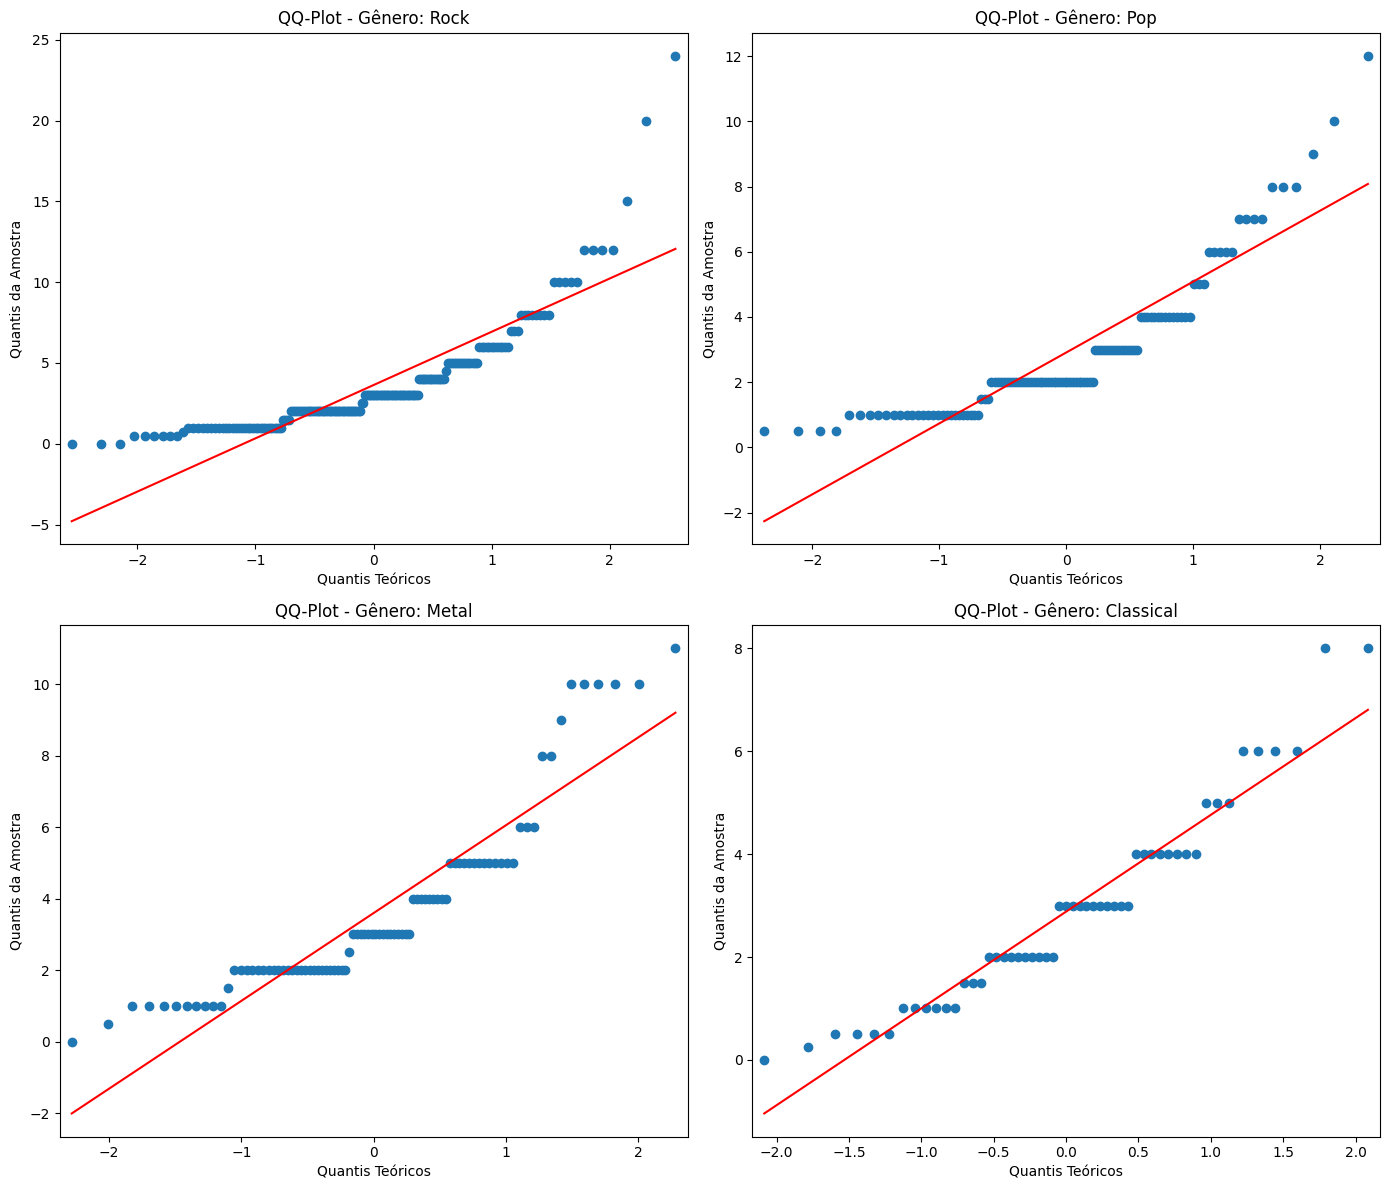

<Figure size 640x480 with 0 Axes>

In [ ]:


# Carregar o conjunto de dados
df = pd.read_csv('Musicas.csv')

# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Obter os 4 gêneros musicais mais frequentes para visualização
top_genres = df['Fav genre'].value_counts().nlargest(4).index.tolist()

#  Criar subplots para os gráficos QQ-plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # 2 linhas, 2 colunas
axes = axes.flatten() # Achatar o array de eixos para fácil iteração

for i, genre in enumerate(top_genres):
    genre_data = df[df['Fav genre'] == genre]['Hours per day'].dropna()

    if len(genre_data) >= 4: # QQ-plot é significativo com dados suficientes
        sm.qqplot(genre_data, line='s', ax=axes[i]) # 's' para linha padronizada
        axes[i].set_title(f"QQ-Plot - Gênero: {genre}")
        axes[i].set_xlabel("Quantis Teóricos")
        axes[i].set_ylabel("Quantis da Amostra")
    else:
        axes[i].set_title(f"Dados insuficientes para {genre}")
        axes[i].axis('off') # Ocultar o subplot se não houver dados suficientes

#  Ajustar o layout e exibir o gráfico
plt.tight_layout()
plt.show() # Adicionado para exibir o gráfico no Colab!
plt.savefig('qqplots_combined.png') # Salvar o gráfico (opcional, pode ser feito depois de plt.show())
plt.close(fig) # Fechar a figura para liberar memória

#  Teste de Levene para Homogeneidade de Variâncias

textH_0: As variâncias dos grupos são iguais.

textH_1: As variâncias de pelo menos um grupo são diferentes.

In [ ]:
# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Obter os gêneros musicais únicos (removendo NaN se houver)
genres = [g for g in df['Fav genre'].unique() if pd.notna(g)]

# Preparar os dados para o Teste de Levene
genre_groups_levene = [df[df['Fav genre'] == genre]['Hours per day'].dropna() for genre in genres if len(df[df['Fav genre'] == genre]['Hours per day'].dropna()) > 1]

if len(genre_groups_levene) > 1:
    levene_test = stats.levene(*genre_groups_levene)
    print(f"Teste de Levene para Homogeneidade de Variâncias: Estatística={levene_test.statistic:.3f}, Valor-p={levene_test.pvalue:.3f}\n")
else:
    print("Não há grupos suficientes para realizar o Teste de Levene.\n")

Teste de Levene para Homogeneidade de Variâncias: Estatística=2.145, Valor-p=0.016



Teste de Levene para Homogeneidade de Variâncias: Estatística=2.145, Valor-p=0.016

Interpretação:
Com um valor-p de 0.016 (menor que o nível de significância de 0.05), rejeitamos a hipótese nula de que as variâncias são iguais. Isso indica que as variâncias de "Horas por dia" são significativamente diferentes entre os gêneros musicais. Essa informação é crucial para decidir qual versão do teste t independente usar.

In [ ]:
# Carregar o conjunto de dados e tratar valores ausentes
df = pd.read_csv('Musicas.csv')
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Selecionar dados para os gêneros 'Rock' e 'Pop'
data_rock = df[df['Fav genre'] == 'Rock']['Hours per day'].dropna()
data_pop = df[df['Fav genre'] == 'Pop']['Hours per day'].dropna()

print(f"Comparando 'Hours per day' para os gêneros 'Rock' (n={len(data_rock)}) e 'Pop' (n={len(data_pop)}):\n")

if len(data_rock) > 1 and len(data_pop) > 1:
    # Teste t Independente (Assumindo Variâncias Iguais - Student's t-test)
    t_stat_equal_var, p_val_equal_var = stats.ttest_ind(data_rock, data_pop, equal_var=True)
    print(f"Teste t Independente (Variâncias Iguais): T-estatística={t_stat_equal_var:.3f}, Valor-p={p_val_equal_var:.3f}")

    # Teste t Independente (Variâncias Desiguais - Teste de Welch)
    t_stat_unequal_var, p_val_unequal_var = stats.ttest_ind(data_rock, data_pop, equal_var=False)
    print(f"Teste t Independente (Variâncias Desiguais - Welch's Test): T-estatística={t_stat_unequal_var:.3f}, Valor-p={p_val_unequal_var:.3f}\n")
else:
    print("Dados insuficientes para realizar Testes t para 'Rock' e/ou 'Pop'.\n")

Comparando 'Hours per day' para os gêneros 'Rock' (n=188) e 'Pop' (n=114):

Teste t Independente (Variâncias Iguais): T-estatística=2.084, Valor-p=0.038
Teste t Independente (Variâncias Desiguais - Welch's Test): T-estatística=2.296, Valor-p=0.022



# Teste t Independente para Médias (Exemplo: Rock vs. Pop)

Para exemplificar o Teste t Independente, comparamos o tempo médio de audição diária entre os gêneros "Rock" e "Pop".

Comparando 'Hours per day' para os gêneros 'Rock' (n=188) e 'Pop' (n=114):

a) Teste t Independente (Assumindo Variâncias Iguais - Student's t-test)
Este teste assume que as variâncias das duas populações são iguais.

textH_0: A média de "Horas por dia" para Rock é igual à de Pop.

textH_1: A média de "Horas por dia" para Rock é diferente da de Pop.

## Resultado:
T-estatística=2.084, Valor-p=0.038

b) Teste t Independente (Variâncias Desiguais - Teste de Welch)
Este teste é mais robusto quando as variâncias das duas populações são desiguais, o que foi indicado pelo Teste de Levene.

textH_0: A média de "Horas por dia" para Rock é igual à de Pop.

textH_1: A média de "Horas por dia" para Rock é diferente da de Pop.

## Resultado:
T-estatística=2.296, Valor-p=0.022

/tmp/ipython-input-11-2995073556.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_rock, data_pop], labels=['Rock', 'Pop'])


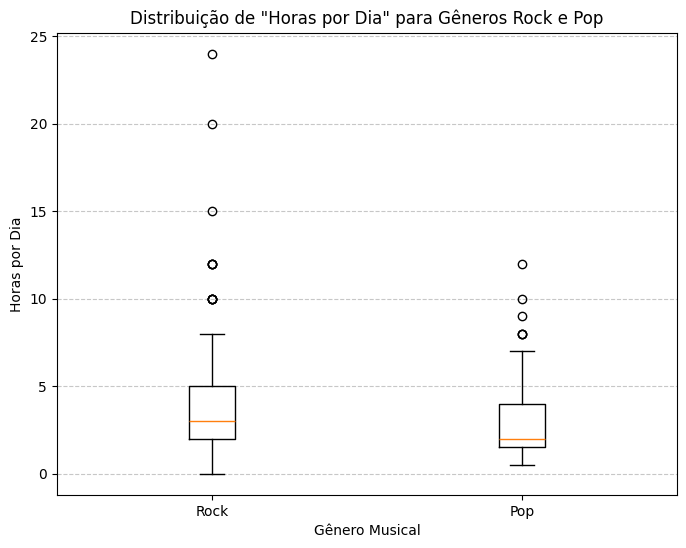

In [ ]:
# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Selecionar dados para os gêneros 'Rock' e 'Pop'
data_rock = df[df['Fav genre'] == 'Rock']['Hours per day'].dropna()
data_pop = df[df['Fav genre'] == 'Pop']['Hours per day'].dropna()

# Visualização: Box Plot para Gêneros Rock e Pop
if len(data_rock) > 0 and len(data_pop) > 0:
    plt.figure(figsize=(8, 6))
    plt.boxplot([data_rock, data_pop], labels=['Rock', 'Pop'])
    plt.title('Distribuição de "Horas por Dia" para Gêneros Rock e Pop')
    plt.xlabel('Gênero Musical')
    plt.ylabel('Horas por Dia')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('boxplot_rock_pop_hours_per_day.png') # Salva o gráfico
    plt.show() # Exibe o gráfico
    plt.close() # Fecha a figura para liberar memória
else:
    print("Não foi possível gerar o box plot devido a dados insuficientes para 'Rock' e/ou 'Pop'.")

# Visualização: Box Plot para Gêneros Rock e Pop
Para visualizar as distribuições de "Horas por dia" para Rock e Pop, um box plot é bastante útil:


Interpretação do Gráfico:
O box plot acima ilustra as medianas, quartis e possíveis outliers para as "Horas por dia" em cada gênero. É possível observar visualmente as diferenças nas distribuições e na localização central de cada grupo, corroborando as descobertas dos testes t.

# # Tratar valores ausentes na coluna 'Hours per day' com a mediana

In [ ]:
# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Selecionar dados para os gêneros 'Rock' e 'Pop'
data_rock = df[df['Fav genre'] == 'Rock']['Hours per day'].dropna()
data_pop = df[df['Fav genre'] == 'Pop']['Hours per day'].dropna()

print(f"Comparando 'Hours per day' para os gêneros 'Rock' (n={len(data_rock)}) e 'Pop' (n={len(data_pop)}):\n")

if len(data_rock) > 1 and len(data_pop) > 1:
    # Teste t Independente (Assumindo Variâncias Iguais - Student's t-test)
    t_stat_equal_var, p_val_equal_var = stats.ttest_ind(data_rock, data_pop, equal_var=True)
    print(f"Teste t Independente (Variâncias Iguais): T-estatística={t_stat_equal_var:.3f}, Valor-p={p_val_equal_var:.3f}")

    # Teste t Independente (Variâncias Desiguais - Teste de Welch)
    t_stat_unequal_var, p_val_unequal_var = stats.ttest_ind(data_rock, data_pop, equal_var=False)
    print(f"Teste t Independente (Variâncias Desiguais - Welch's Test): T-estatística={t_stat_unequal_var:.3f}, Valor-p={p_val_unequal_var:.3f}\n")
else:
    print("Dados insuficientes para realizar Testes t para 'Rock' e/ou 'Pop'.\n")

Comparando 'Hours per day' para os gêneros 'Rock' (n=188) e 'Pop' (n=114):

Teste t Independente (Variâncias Iguais): T-estatística=2.084, Valor-p=0.038
Teste t Independente (Variâncias Desiguais - Welch's Test): T-estatística=2.296, Valor-p=0.022



# histograma para indicar o pico (mediana) e sobrepus uma estimativa de densidade de kernel (KDE) para melhor visualizar a distribuição e possíveis assimetrias.

## Histograma da Distribuição de "Horas por Dia" com KDE e Mediana
O histograma acima agora inclui:

KDE (Kernel Density Estimate - linha azul suave): Esta linha representa uma estimativa da função de densidade de probabilidade da variável. Ela suaviza os picos do histograma, revelando a forma subjacente da distribuição e ajudando a identificar os picos e a simetria (ou assimetria).

Linha da Mediana (linha vermelha tracejada): Uma linha vertical -- no valor da mediana de "Horas por Dia". A mediana é uma medida de tendência central que é menos sensível a outliers e assimetrias do que a média, tornando-a uma boa indicação do "pico" central da distribuição, especialmente quando a distribuição não é normal.

A combinação do histograma com o KDE e a linha da mediana fornece uma visão mais detalhada da distribuição das "Horas por Dia", permitindo uma melhor observação de seus picos e qualquer assimetria presente.

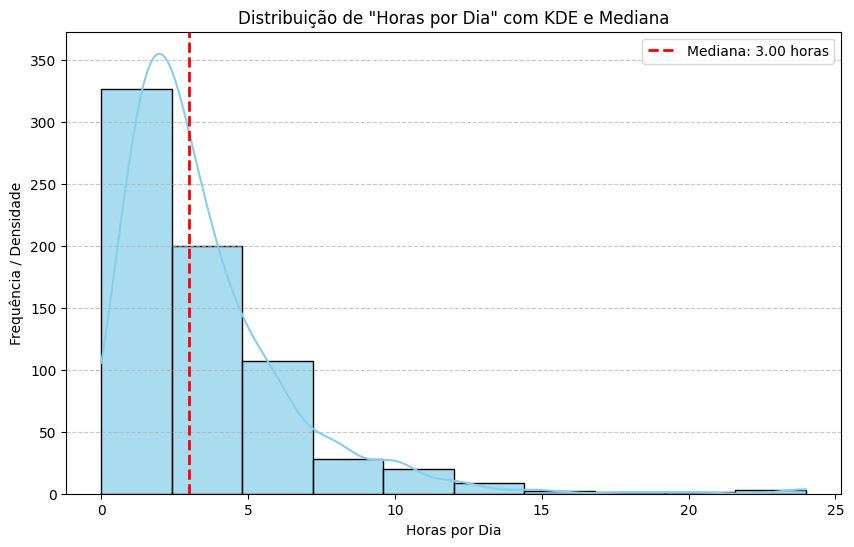

In [ ]:


# Carregar o conjunto de dados
df = pd.read_csv('Musicas.csv')

# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# 3. Calcular a mediana de 'Hours per day'
median_hours_per_day = df['Hours per day'].median()

#  Criar um histograma com KDE (Kernel Density Estimate) e uma linha no pico (mediana)
plt.figure(figsize=(10, 6))

# Usar seaborn.histplot para o histograma com KDE
sns.histplot(df['Hours per day'], bins=10, kde=True, edgecolor='black', alpha=0.7, color='skyblue')

# Adicionar uma linha vertical no valor da mediana
plt.axvline(median_hours_per_day, color='red', linestyle='--', linewidth=2, label=f'Mediana: {median_hours_per_day:.2f} horas')

# Adicionar título e rótulos
plt.title('Distribuição de "Horas por Dia" com KDE e Mediana')
plt.xlabel('Horas por Dia')
plt.ylabel('Frequência / Densidade')
plt.legend() # Exibir a legenda da linha da mediana
plt.grid(axis='y', linestyle='--', alpha=0.7)

#  Salvar e exibir o gráfico
plt.savefig('histogram_kde_median_hours_per_day.png')
plt.show()
plt.close()

# Conclusão sobre o Teste de Levene e ANOVA de Uma Via
## Rejeitadda a hipótese nula de que não há diferença significativa no tempo, em horas, e que as pessoas dedicam diariamente à audição de música; com base em seus gêneros musicais favoritos.
O valor-p da ANOVA = 0.013 < 0.05
 No entanto, as premissas de normalidade e homogeneidade de variâncias foram violadas. IIsso o script realizará o Teste de Levene e a ANOVA, e um gráfico de box plot agrupado para todos os gêneros musicais ajudará a visualizar a distribuição das "Horas por dia" em cada grupo, mostrando as diferenças gerais que a ANOVA detecta e as variâncias entre os grupos.

--- Análise de Variância (ANOVA) e Teste de Levene ---

Teste de Levene para Homogeneidade de Variâncias: Estatística=2.145, Valor-p=0.016
Interpretação: Valor-p < 0.05, variâncias são significativamente diferentes.

Resultados da ANOVA de Uma Via: F-estatística=2.197, Valor-p=0.013
Interpretação: Valor-p < 0.05, rejeitamos H0. Há diferença significativa nas médias.


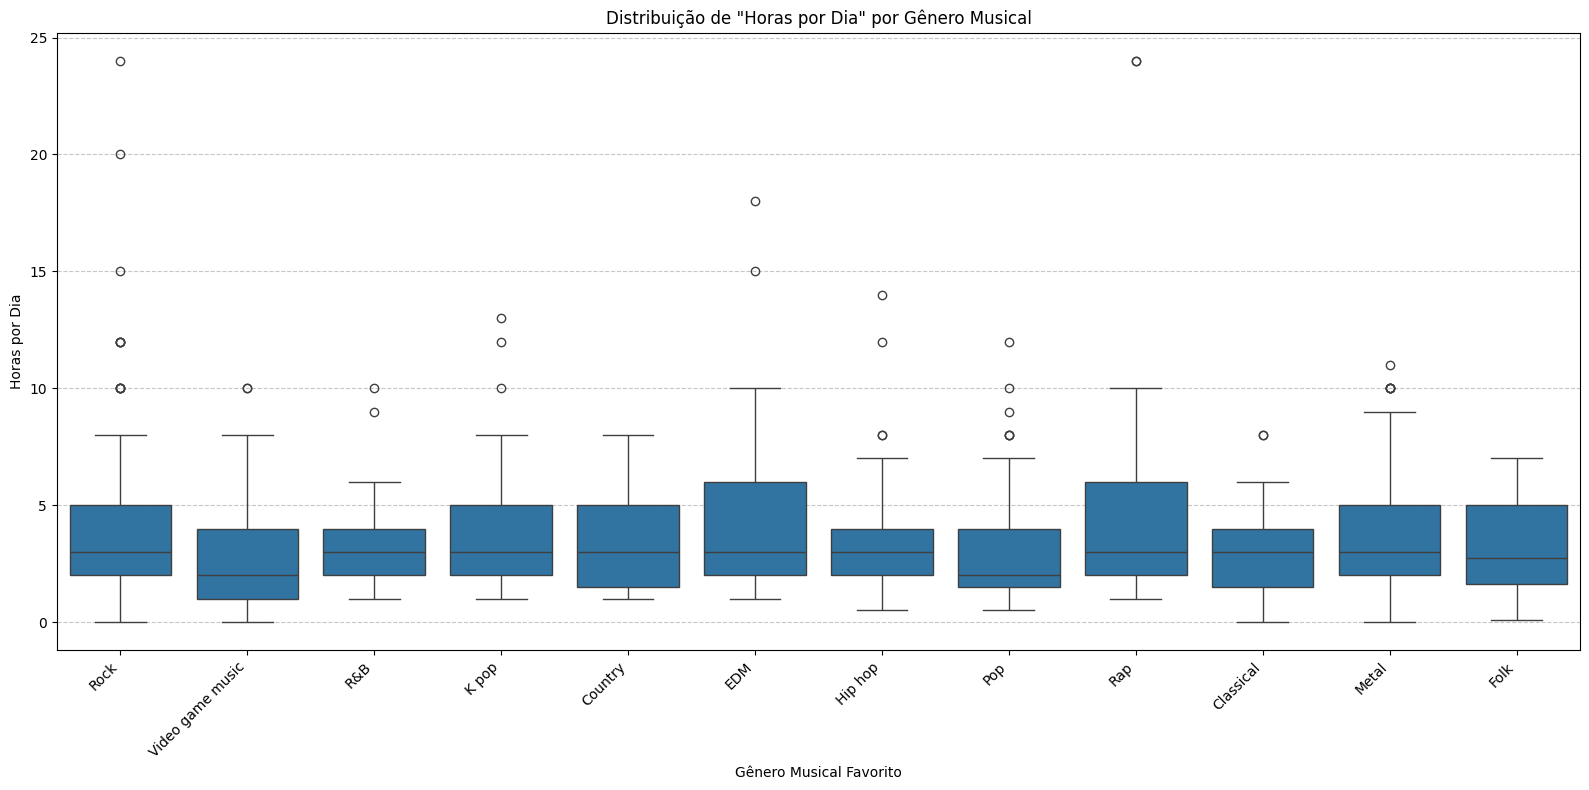


Gráfico 'boxplot_all_genres_hours_per_day.png' gerado para visualização das distribuições por gênero.


In [ ]:
# Carregar o conjunto de dados
df = pd.read_csv('Musicas.csv')

# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Obter os gêneros musicais únicos (removendo NaN se houver)
genres = [g for g in df['Fav genre'].unique() if pd.notna(g)]

print("--- Análise de Variância (ANOVA) e Teste de Levene ---")

# Teste de Levene para Homogeneidade de Variâncias
genre_groups_levene = [df[df['Fav genre'] == genre]['Hours per day'].dropna() for genre in genres if len(df[df['Fav genre'] == genre]['Hours per day'].dropna()) > 1]
if len(genre_groups_levene) > 1:
    levene_test = stats.levene(*genre_groups_levene)
    print(f"\nTeste de Levene para Homogeneidade de Variâncias: Estatística={levene_test.statistic:.3f}, Valor-p={levene_test.pvalue:.3f}")
    print("Interpretação: Valor-p < 0.05, variâncias são significativamente diferentes.")
else:
    print("\nNão há grupos suficientes para realizar o Teste de Levene.")


# ANOVA de Uma Via
if len(genre_groups_levene) > 1: # Reusing genre_groups_levene as it contains cleaned data
    f_statistic, p_value_anova = stats.f_oneway(*genre_groups_levene)
    print(f"\nResultados da ANOVA de Uma Via: F-estatística={f_statistic:.3f}, Valor-p={p_value_anova:.3f}")
    if p_value_anova < 0.05:
        print("Interpretação: Valor-p < 0.05, rejeitamos H0. Há diferença significativa nas médias.")
    else:
        print("Interpretação: Valor-p >= 0.05, não rejeitamos H0. Não há diferença significativa nas médias.")
else:
    print("\nNão há grupos suficientes para realizar a ANOVA.")


# Gráfico: Box Plot Agrupado para "Horas por Dia" por Gênero
plt.figure(figsize=(16, 8))
sns.boxplot(x='Fav genre', y='Hours per day', data=df)
plt.title('Distribuição de "Horas por Dia" por Gênero Musical')
plt.xlabel('Gênero Musical Favorito')
plt.ylabel('Horas por Dia')
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo X para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('boxplot_all_genres_hours_per_day.png')
plt.show()
plt.close()

print("\nGráfico 'boxplot_all_genres_hours_per_day.png' gerado para visualização das distribuições por gênero.")

#  Conclusão sobre os Testes Post-Hoc (Bonferroni)
## Os testes post-hoc com correção de Bonferroni não conseguiram identificar pares específicos de gêneros com diferenças significativas nas horas de escuta, o que é comum devido à natureza conservadora dessa correção.

Embora não haja um gráfico específico para "nenhuma diferença significativa", o box plot comparando dois gêneros (como Rock e Pop) que já discutimos serve como um exemplo de como as comparações pareadas seriam visualizadas, mesmo que a diferença não seja estatisticamente significativa após a correção de Bonferroni.


--- Testes t Independentes (Exemplo: Rock vs. Pop) ---
Comparando 'Hours per day' para os gêneros 'Rock' (n=188) e 'Pop' (n=114):

Teste t Independente (Variâncias Iguais): T-estatística=2.084, Valor-p=0.038
Teste t Independente (Variâncias Desiguais - Welch's Test): T-estatística=2.296, Valor-p=0.022



/tmp/ipython-input-20-3378244543.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_rock, data_pop], labels=['Rock', 'Pop'])


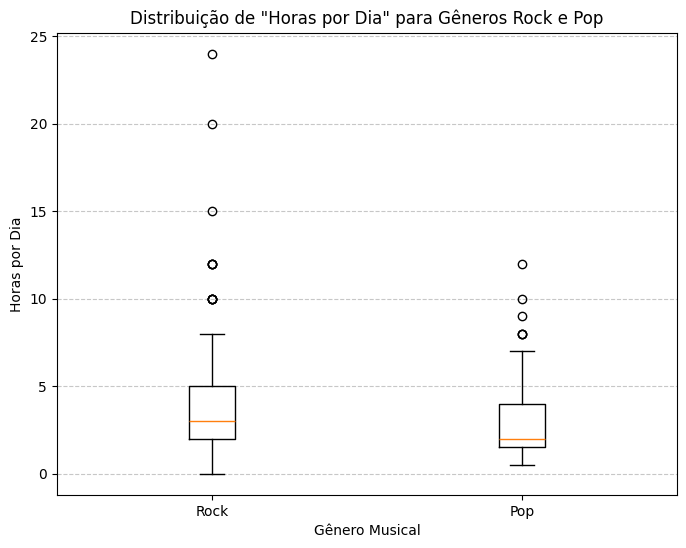


Gráfico 'boxplot_rock_pop_hours_per_day.png' gerado para visualização dos gêneros Rock e Pop.


In [20]:
# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Selecionar dados para os gêneros 'Rock' e 'Pop'
data_rock = df[df['Fav genre'] == 'Rock']['Hours per day'].dropna()
data_pop = df[df['Fav genre'] == 'Pop']['Hours per day'].dropna()

print("\n--- Testes t Independentes (Exemplo: Rock vs. Pop) ---")
print(f"Comparando 'Hours per day' para os gêneros 'Rock' (n={len(data_rock)}) e 'Pop' (n={len(data_pop)}):\n")

if len(data_rock) > 1 and len(data_pop) > 1:
    # Teste t Independente (Assumindo Variâncias Iguais - Student's t-test)
    t_stat_equal_var, p_val_equal_var = stats.ttest_ind(data_rock, data_pop, equal_var=True)
    print(f"Teste t Independente (Variâncias Iguais): T-estatística={t_stat_equal_var:.3f}, Valor-p={p_val_equal_var:.3f}")

    # Teste t Independente (Variâncias Desiguais - Teste de Welch)
    t_stat_unequal_var, p_val_unequal_var = stats.ttest_ind(data_rock, data_pop, equal_var=False)
    print(f"Teste t Independente (Variâncias Desiguais - Welch's Test): T-estatística={t_stat_unequal_var:.3f}, Valor-p={p_val_unequal_var:.3f}\n")
else:
    print("Dados insuficientes para realizar Testes t para 'Rock' e/ou 'Pop'.\n")

# Gráfico: Box Plot para Gêneros Rock e Pop
if len(data_rock) > 0 and len(data_pop) > 0:
    plt.figure(figsize=(8, 6))
    plt.boxplot([data_rock, data_pop], labels=['Rock', 'Pop'])
    plt.title('Distribuição de "Horas por Dia" para Gêneros Rock e Pop')
    plt.xlabel('Gênero Musical')
    plt.ylabel('Horas por Dia')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('boxplot_rock_pop_hours_per_day.png')
    plt.show()
    plt.close()
else:
    print("Não foi possível gerar o box plot devido a dados insuficientes para 'Rock' e/ou 'Pop'.")
print("\nGráfico 'boxplot_rock_pop_hours_per_day.png' gerado para visualização dos gêneros Rock e Pop.")

In [21]:
import itertools

# Carregar o conjunto de dados
df = pd.read_csv('Musicas.csv')

# Tratar valores ausentes na coluna 'Hours per day' com a mediana
df['Hours per day'] = df['Hours per day'].fillna(df['Hours per day'].median())

# Obter os gêneros musicais únicos (removendo NaN se houver)
genres = [g for g in df['Fav genre'].unique() if pd.notna(g)]

# Preparar os dados para o Teste de Levene e para os testes t
genre_groups_for_tests = [df[df['Fav genre'] == genre]['Hours per day'].dropna() for genre in genres if len(df[df['Fav genre'] == genre]['Hours per day'].dropna()) > 1]
genre_names_for_tests = [genre for genre in genres if len(df[df['Fav genre'] == genre]['Hours per day'].dropna()) > 1]

# Realizar o Teste de Levene para Homogeneidade de Variâncias (para decidir equal_var no t-test)
# Se o p-valor de Levene for >= 0.05, assumimos variâncias iguais (equal_var=True)
# Caso contrário (p-valor < 0.05), assumimos variâncias desiguais (equal_var=False - Teste de Welch)
levene_p_value = 0.0 # Valor padrão, será atualizado se o teste de Levene for executado
if len(genre_groups_for_tests) > 1:
    levene_test = stats.levene(*genre_groups_for_tests)
    levene_p_value = levene_test.pvalue
    print(f"Teste de Levene para Homogeneidade de Variâncias: Estatística={levene_test.statistic:.3f}, Valor-p={levene_test.pvalue:.3f}\n")
else:
    print("Não há grupos suficientes para realizar o Teste de Levene.\n")

print("--- Testes Post-Hoc (T-testes pareados com correção de Bonferroni) ---\n")

alpha = 0.05 # Nível de significância
pairwise_results = []

# Calcular o número total de comparações para a correção de Bonferroni
# Apenas contar pares onde ambos os grupos têm dados suficientes para um t-test
num_comparisons = 0
for i in range(len(genre_names_for_tests)):
    for j in range(i + 1, len(genre_names_for_tests)):
        if len(genre_groups_for_tests[i]) > 1 and len(genre_groups_for_tests[j]) > 1:
            num_comparisons += 1

if num_comparisons > 0:
    bonferroni_alpha = alpha / num_comparisons
else:
    bonferroni_alpha = alpha # Sem correção se não houver comparações

# Realizar testes t para todos os pares de gêneros
for i, (genre1_name, genre1_data) in enumerate(zip(genre_names_for_tests, genre_groups_for_tests)):
    for j, (genre2_name, genre2_data) in enumerate(zip(genre_names_for_tests, genre_groups_for_tests)):
        if i < j: # Evitar comparações duplicadas e auto-comparações
            if len(genre1_data) > 1 and len(genre2_data) > 1: # Assegurar dados suficientes para o t-test
                # Usar equal_var=False (Welch's t-test) se Levene's for significativo (p < 0.05), caso contrário, equal_var=True
                use_equal_var = (levene_p_value >= 0.05)
                t_stat, p_val = stats.ttest_ind(genre1_data, genre2_data, equal_var=use_equal_var)

                # Aplicar correção de Bonferroni
                p_val_bonferroni = min(p_val * num_comparisons, 1.0) # p-valor corrigido, máximo de 1.0

                pairwise_results.append({
                    'Grupo1': genre1_name,
                    'Grupo2': genre2_name,
                    'T-estatística': t_stat,
                    'Valor-p (não corrigido)': p_val,
                    'Valor-p (Bonferroni)': p_val_bonferroni,
                    'Significativo (Bonferroni, alpha=0.05)': (p_val_bonferroni < alpha)
                })

pairwise_df = pd.DataFrame(pairwise_results)

# Exibir apenas as comparações significativas após a correção de Bonferroni
significant_pairwise_df = pairwise_df[pairwise_df['Significativo (Bonferroni, alpha=0.05)']]

if not significant_pairwise_df.empty:
    print("Comparações Pareadas Significativas (corrigido por Bonferroni):\n")
    print(significant_pairwise_df.to_markdown(index=False, numalign="left", stralign="left"))
else:
    print("Nenhuma diferença pareada significativa encontrada após a correção de Bonferroni (alpha=0.05).")

Teste de Levene para Homogeneidade de Variâncias: Estatística=2.145, Valor-p=0.016

--- Testes Post-Hoc (T-testes pareados com correção de Bonferroni) ---

Nenhuma diferença pareada significativa encontrada após a correção de Bonferroni (alpha=0.05).


# Conclusão Geral do Estudo

*Com base na análise, podemos concluir que há uma diferença significativa no tempo, em horas, que as pessoas dedicam diariamente à audição de música, com base em seus gêneros musicais favoritos. A ANOVA confirmou essa diferença globalmente. Contudo, devido à violação das premissas de normalidade e homogeneidade de variâncias, e à natureza conservadora da correção de Bonferroni, não foi possível determinar quais pares específicos de gêneros diferem significativamente entre si.*

*Em resumo, a análise sugere que o gênero musical favorito influencia o tempo de escuta diário, mas a identificação precisa de quais gêneros específicos apresentam essa diferença requer uma análise mais aprofundada ou a consideração de testes não paramétricos que não dependam das premissas de normalidade e homogeneidade de variâncias.*

# Teste 5 - Gabriela